# Imports

In [1]:
import os
from typing import *
import itertools
from pathlib import Path
import zstandard as zstd
from dataclasses import dataclass
import random
import gc
import h5py
import yaml

import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from tqdm.notebook import tqdm

import torch
from torch import Tensor, nn, optim
from torch.nn import Parameter
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

from evo import Evo

import Bio
from Bio import SeqIO


""" cache directory. """
NOTEBOOK_CACHE = Path("__tmp") / "american_gut_USCA"
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

In [2]:
with open("hf_token.txt", "rt") as f:
    token = f.readline().strip()
    assert len(token) > 0, "File 'hf_token.txt' should contain the hugging face token in the first line."
    os.environ["HF_TOKEN"] = token
    print("Successfully set huggingface token from file 'hf_token.txt'!")

Successfully set huggingface token from file 'hf_token.txt'!


# Dataset files.

## File locations & metadata.

In [3]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
microbiome_sequencing_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert microbiome_sequencing_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert microbiome_sequencing_dir.is_dir(), f"Expected {microbiome_sequencing_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


In [4]:
# american gut: PRJEB11419
project_metadata.loc[
    (project_metadata['condition'] == 'healthy') & (project_metadata['amplicon'] == 'v4'),
    :
]

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
50,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN
52,PRJEB32547,https://doi.org/10.1016/j.clnu.2020.12.034,v4,97.72,True,custom,stool,healthy,adults and elderly,Repeated-Bead-Beating and purified using the M...
61,PRJEB38457,https://doi.org/10.1038/s41467-020-20495-4,v4,201.89,True,Power Soil DNA Isolation Kit,stool,healthy,children,NaN
64,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
74,PRJEB32537,https://doi.org/10.3390/nu11051135,v4,227.00,True,MoBio PowerMag microbiome kit,stool,healthy,adults,NaN
99,PRJEB6705,https://doi.org/10.1016/j.cell.2014.09.053,v4,226.92,True,PowerSoil - htp DNA isolation kit (MoBio Labor...,stool,healthy,adults,NaN
100,PRJEB6702,https://doi.org/10.1016/j.cell.2014.09.053,v4,203.00,True,PowerSoil - htp DNA isolation kit (MoBio Labor...,stool,healthy,adults,NaN
102,PRJEB6518,https://doi.org/10.1186/gb-2014-15-7-r89,v4,72.05,True,QIAamp DNA Stool Mini Kit (Qiagen),"stool, saliva",healthy,adults,NaN


In [5]:
def print_project_info(proj_id: str):
    sample_section = sample_metadata.loc[sample_metadata['project'] == proj_id]
    regions = pd.unique(sample_section['region'])
    isos = pd.unique(sample_section['iso'])
    n_samples = sample_section.shape[0]
    print(f"Project: {proj_id}")
    print(f"\tregions: {regions}")
    print(f"\tisos: {isos}")
    print(f"\tnum samples: {n_samples}")

print_project_info("PRJEB11419")
print_project_info("PRJEB36316")
print_project_info("PRJEB20773")

Project: PRJEB11419
	regions: ['unknown' 'Europe and Northern America'
 'Northern Africa and Western Asia' 'Australia/New Zealand'
 'Eastern and South-Eastern Asia' 'Sub-Saharan Africa'
 'Latin America and the Caribbean' 'Central and Southern Asia' 'Oceania']
	isos: ['unknown' 'GB' 'US' 'FR' 'IS' 'AT' 'SE' 'CA' 'CH' 'AM' 'NZ' 'GR' 'NO'
 'MY' 'NL' 'HU' 'KE' 'CO' 'IL' 'BD' 'ES' 'DK' 'BE' 'IE' 'DE' 'AU' 'ZW'
 'FI' 'IT' 'IN' 'UM' 'AE' 'UG' 'PT' 'HR' 'LT' 'TR' 'PL' 'BR' 'SG' 'PE']
	num samples: 4850
Project: PRJEB36316
	regions: ['Europe and Northern America']
	isos: ['NL']
	num samples: 100
Project: PRJEB20773
	regions: ['Central and Southern Asia']
	isos: ['IN']
	num samples: 280


## Functions.

In [6]:
def get_asv_sequences() -> Iterator[Tuple[str, str]]:
    """ 
    Fetch all of the ASV sequences from the asv_sequence_file location. 
    :return: A generator over (<ASV_ID>, <ASV_SEQ>) tuples.
    """
    with zstd.open(asv_sequence_file, "rt") as f:
        header_line = f.readline()
        assert header_line.startswith("#OTU"), "Expected file to start with the header: `#OTU`"
        
        for line in f:
            tokens = line.strip().split("\t")
            assert len(tokens) == 2, f"Expected exactly two tokens. Got: {line}"

            asv_id, asv_seq = tokens[0], tokens[1]
            assert asv_id.startswith("ASV"), f"Expected token #1 to have prefix `ASV`. Got: {asv_id}"
            yield asv_id, asv_seq


@dataclass
class SampleMetadata:
    library_strategy: str
    library_source: str
    total_bases: int
    instrument: str
    geo_loc_name: str
    iso: str
    region: str


class MicrobiomeSample:
    def __init__(self, sample_id: str):
        self.sample_id = sample_id
        self.read_counts: Dict[str, float] = dict()
        self._metadata = None

    @property
    def asv_ids(self) -> Set[str]:
        return set(self.read_counts.keys())

    def set_count(self, asv_id: str, count_value: int) -> None:
        self.read_counts[asv_id] = count_value

    @property
    def metadata(self) -> SampleMetadata:
        if self._metadata is None:
            df_row = sample_metadata.loc[sample_metadata['srs'] == self.sample_id]
            assert df_row.shape[0] == 1, "Expected 1 row of metadata for id {}, got: {}".format(self.sample_id, df_row.shape[0])
            df_row = df_row.head(1)
            self._metadata = SampleMetadata(
                df_row['library_strategy'], df_row['library_source'], df_row['total_bases'], 
                df_row['instrument'], df_row['geo_loc_name'], df_row['iso'], df_row['region']
            )
        return self._metadata

    def read_count_array(self, asv_id_subset: Optional[Set[str]] = None) -> Tuple[List[str], np.ndarray]:
        """
        Return read counts, formatted as a numpy array.
        Note that the ordering of the read counts is not guaranteed, and may depend on python version! Check the List[str] part of this method's output for the resulting order.
        :return: A pair (asv_ids, read_counts), where `read_counts` is the numpy array, and `asv_ids` is the order of the ASVs indexing the array.
        """
        if asv_id_subset is None:
            target_asv_ids = self.asv_ids
        else:
            target_asv_ids = asv_id_subset.intersection(self.asv_ids)
            
        asv_ids = []
        asv_reads = []
        for asv_id in target_asv_ids:
            asv_read_count = self.read_counts[asv_id]
            asv_ids.append(asv_id)
            asv_reads.append(asv_read_count)
        return asv_ids, np.array(asv_reads, dtype=int)

    def relative_abundance_array(self, asv_id_subset: Optional[Set[str]] = None) -> Tuple[List[str], np.ndarray]:
        """
        Return estimated relative abundances, formatted as a numpy array.
        :return: A pair (asv_ids, rel_abunds), where `rel_abunds` is the numpy array, and `asv_ids` is the order of the ASVs indexing the array.
        """
        asv_ids, read_counts = self.read_count_array(asv_id_subset)
        return asv_ids, read_counts / np.sum(read_counts)

    def num_asvs(self) -> int:
        return len(self.read_counts)

    def __str__(self) -> str:
        return self.sample_id

    def __repr__(self) -> str:
        return f"Sample[{self.sample_id}]"


class MicrobiomeProject:
    def __init__(self, project_id: str):
        self.project_id = project_id
        self.samples = self.get_microbiome_sequencing(project_id)

    def __str__(self) -> str:
        return "Project[{}]".format(self.project_id)

    def __repr__(self) -> str:
        return "Project[{}]".format(self.project_id)

    @staticmethod
    def get_microbiome_sequencing(project_id) -> List[MicrobiomeSample]:    
        samples: List[MicrobiomeSample] = []
        with zstd.open(microbiome_sequencing_dir / f"{project_id}.txt.zst", "rt") as f:
            header_line = f.readline()
            assert header_line.startswith("asv\t"), f"Expected file to start with the header: `asv\\t`. Got: {header_line}"
    
            tokens = header_line.strip().split("\t")[1:]
            for sample_id in tokens:
                assert sample_id.startswith("DRS") or sample_id.startswith("SRS") or sample_id.startswith("ERS"), f"In {project_id}, expected sample ID to start with `DRS`, `SRS` or `ERS`. Got: {sample_id}"
                samples.append(MicrobiomeSample(sample_id))
    
            for line_idx, line in enumerate(f):
                tokens = line.strip().split("\t")
                asv_id = tokens[0]
                assert asv_id.startswith("ASV"), f"In {project_id}, line {line_idx+1}, expected asv ID to start with `ASV`. Got: {asv_id}"
    
                assert len(tokens) == len(samples) + 1, f"In {project_id}, line {line_idx+1}, expected line to have {len(samples)+1} columns. Got: {len(tokens)}"
                for value_str, sample_obj in zip(tokens[1:], samples):
                    if value_str == "0.0":
                        continue
                    else:
                        sample_obj.set_count(asv_id, int(float(value_str)))
        return samples

## Load dataset.

### Complete set of ASVs.

In [7]:
""" Load ASV nucleotide sequences. """
asv_seqs_all = {}
for asv_id, asv_seq in get_asv_sequences():
    asv_seqs_all[asv_id] = asv_seq

print("# ASVs:", len(asv_seqs_all))

# ASVs: 3663370


### Select subset of projects, samples and ASVs.

Also compute global parameters: 
- MAX_NUM_ASVS
- MAX_ASV_SEQUENCE_LEN

In [8]:
"""
First, filter by project ID (American Gut, PRJEB11419) and restrict to US/CA subjects and Illumina MiSeq experiments.
Then, filter out those samples which have an abnormal amount of read counts (outside of 2.5% <--> 97.5% quantile)
"""
project_subset = project_metadata.loc[
    (project_metadata['condition'] == 'healthy') & (project_metadata['amplicon'] == 'v4') & (project_metadata['project'] == 'PRJEB11419'), 
    :
]

sample_subset = sample_metadata.loc[
    sample_metadata['iso'].isin({"US", "CA"})                            # filter by region.
    & sample_metadata['project'].isin(set(project_subset['project']))    # filter by results of "project_subset".
    & (sample_metadata['instrument'] == 'Illumina MiSeq')                # filter by sequencing instrument.
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

# ========== attach read depth (total # of ASV reads) as a column.
sample_total_read_counts_all = []
for proj_id, proj_section in sample_subset.groupby('project'):
    with zstd.open(microbiome_sequencing_dir / f"{proj_id}.txt.zst", "rt") as f:
        counts_table = pd.read_csv(f, sep='\t').set_index("asv")    # load from file
        counts_table = counts_table[list(proj_section['srs'])]      # restroct to samples from sample_subset
        sample_total_reads = counts_table.sum(axis=0)               # compute total ASV read counts in each sample
        sample_total_read_counts_all.append(sample_total_reads)     # append to list for concatenation.

sample_total_read_counts_all = pd.concat(sample_total_read_counts_all).rename("read_counts").astype(int)
assert sample_total_read_counts_all.shape[0] == sample_subset.shape[0], f"Expected read count for each sample. Got: {sample_total_read_counts_all.shape[0]} vs {sample_subset.shape[0]}"

sample_subset = sample_subset.merge(
    sample_total_read_counts_all.to_frame(),
    left_on=['srs'], right_index=True,
    how='left'
)

# ========== filter by read count threshold. (perform this on a per-project basis)
sections = []
for proj_id, sample_project_section in sample_subset.groupby("project"):
    print(f"[Project {proj_id}] Read count statistics:")
    display(sample_project_section['read_counts'].describe().to_frame())

    read_count_ub = np.quantile(sample_project_section['read_counts'], q=0.975)
    read_count_lb = np.quantile(sample_project_section['read_counts'], q=0.025)
    print(f"[Project {proj_id}] Using read count threshold of {read_count_lb} < x < {read_count_ub}")
    sample_project_section = sample_project_section.loc[
        (sample_project_section['read_counts'] <= read_count_ub) & (sample_project_section['read_counts'] >= read_count_lb)
    ]
    sections.append(sample_project_section)
    print("*********************************")

sample_subset = pd.concat(sections, ignore_index=True)
print("[*] Stage 2 filter: {} samples remaining".format(sample_subset.shape[0]))
del sections

display(sample_subset.groupby('project')['iso'].value_counts().rename("count").to_frame())

# ========== Now cross-reference back after filtering by region/read depth.
project_subset = project_subset.loc[project_subset['project'].isin(set(sample_subset['project']))]

[*] Stage 1 filter: 1463 samples remaining
[Project PRJEB11419] Read count statistics:


,read_counts
count,1463.000000
mean,26387.110731
std,14416.527274
min,1.000000
25%,18309.000000
50%,23894.000000
75%,32628.000000
max,362398.000000


[Project PRJEB11419] Using read count threshold of 9620.400000000001 < x < 51783.150000000016
*********************************
[*] Stage 2 filter: 1389 samples remaining


count
project    iso       
PRJEB11419 US    1267
           CA     122

In [9]:
"""
Next, restrict the set of ASVs to only those found in the filtered set of samples.
Apply an additional filter on the ASVs: only keep ASVs which appear in >=1 sample with a read count of >=10.
Finally, remove samples with 0 of these filtered ASVs.
"""
def select_subset_asvs(project_ids: List[str], sample_subset: Set[str]) -> Tuple[Set[str], int, Set[str]]:
    """
    :return: A triple of objects (Set of ASV IDs, Max # of ASV per sample, subset of sample IDs). 
    The subset of sample IDs is guaranteed to be a subset of the input 'sample_subset'; it should be used for further downstream pre-filtering of samples.
    """
    asv_set = set()
    max_sample_asv = 0
    new_sample_id_subset = set()
    for project_id in project_ids:
        with zstd.open(microbiome_sequencing_dir / f"{project_id}.txt.zst", "rt") as f:
            table = pd.read_csv(f, sep='\t').set_index("asv")
            table = table[list(sample_subset)]
            print("[* Pre-ASV selection filtering] PROJECT {}: {} samples, {} ASVs".format(project_id, len(table.columns), len(table.index)))

            # # ============ debug
            # read_depths = table.sum(axis=0)
            # fig, ax = plt.subplots(1, 1)
            # sb.histplot(read_depths, ax=ax)
            
            # _counts = table.to_numpy() 
            # _counts_sum_across_samples = np.sum(_counts, axis=1)  # PER ASV: total counts across samples, dimension of array = (# asvs)
            # print("# asvs with total reads > 5 across samples: {}".format(
            #     np.sum(_counts_sum_across_samples > 5)
            # ))
            # fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            # for sample_filter in [1, 2, 3, 4, 5]:  ## each curve
            #     _asv_counts = []
            #     count_ticks = [1, 2, 3, 4, 5, 6, 7, 8, 9]
            #     for ct_filter in count_ticks:  # x-axis
            #         _thresholded_presence_per_asv_per_sample = (_counts >= ct_filter)  # table [ASV x SAMPLE]
            #         _counts_thresholded_samples = np.sum(_thresholded_presence_per_asv_per_sample, axis=1)  # PER ASV: how many samples with count > 2, dimension of array = (# asvs)
            #         # Example: _counts_thresholded_samples = [ASV0: 1 sample, ASV1: 5 sample, ASV2: 10 sample, ...]
            #         y_to_plot = np.sum(_counts_thresholded_samples >= sample_filter)  # how many ASVS meeting criteria: at least `sample_filter` samples with count > 2
            #         _asv_counts.append(int(y_to_plot))
            #     ax.plot(count_ticks, _asv_counts, label='sample filter = {}'.format(sample_filter))
            #         # print("# asvs present (present means > 2 reads in sample) in more than 1 samples: {}".format(
            #         #     np.sum(_counts_thresholded_samples >= 1)
            #         # ))
            # ax.set_xticks(count_ticks)
            # ax.set_xlabel('Count filter')
            # ax.set_yscale('log')
            # plt.legend()
            # # ============ end debug

            read_count_lb = 10
            num_sample_lb = 1

            print(f"Filtering ASVs by (# samples with count >= {read_count_lb}) >= {num_sample_lb}")
            asv_n_samples = np.sum(table >= read_count_lb, axis=1)  # per asv: which samples have this ASV with count >= 3? Then count the # of samples (np.sum)
            table = table.loc[asv_n_samples >= num_sample_lb, :]    # restrict table to those ASVs where # samples (satisfying above threshold) >= 3

            min_num_asv = 50
            print(f"Filtering samples by (# filtered asv) >= {min_num_asv}")
            num_asv_per_sample = np.sum(table > 0, axis=0)
            samples_with_lb_asvs = num_asv_per_sample.loc[num_asv_per_sample >= min_num_asv]
            table = table.loc[:, samples_with_lb_asvs.index.to_list()]
            
            # ======= DEBUG
            # display(num_asv_per_sample.sort_values())
            # fig, ax = plt.subplots(1, 1)
            # ax.hist(num_asv_per_sample, bins=20)
            # ax.set_ylabel('# of samples')
            # ax.set_xlabel('# of ASVs')
            # ======= END DEBUG

            print("[* Post-ASV selection filtering] PROJECT {}: {} samples, {} ASVs".format(project_id, len(table.columns), len(table.index)))
            for sample_id in table.columns.to_list():
                new_sample_id_subset.add(sample_id)
                sample_n_asvs = np.sum(table[sample_id] > 0)
                max_sample_asv = max(max_sample_asv, sample_n_asvs)
            
            for asv_id in table.index.to_list():
                asv_set.add(asv_id)
    return asv_set, max_sample_asv, new_sample_id_subset 


asv_id_subset, MAX_NUM_ASVS, sample_id_subset_post_filter = select_subset_asvs(project_subset['project'].to_list(), sample_subset=set(sample_subset['srs'].tolist()))
print("Num. project-relevant ASVs:", len(asv_id_subset))
print("Per-sample max num. ASV:", MAX_NUM_ASVS)

# ======= Update the sample_subset and project_subset dataframes, since we removed some samples with 0 filtered ASVs.
sample_subset = sample_subset.loc[sample_subset['srs'].isin(sample_id_subset_post_filter)]
project_subset = project_subset.loc[project_subset['project'].isin(set(sample_subset['project']))]

# ======= Fetch the ASV sequences.
asv_seqs_subset = {
    asv_id: asv_seq 
    for asv_id, asv_seq in asv_seqs_all.items() 
    if asv_id in asv_id_subset
}

assert len(asv_seqs_subset) == len(asv_id_subset)

[* Pre-ASV selection filtering] PROJECT PRJEB11419: 1389 samples, 24528 ASVs
Filtering ASVs by (# samples with count >= 10) >= 1
Filtering samples by (# filtered asv) >= 50
[* Post-ASV selection filtering] PROJECT PRJEB11419: 1307 samples, 7167 ASVs
Num. project-relevant ASVs: 7167
Per-sample max num. ASV: 331


In [10]:
""" Finally, run BLAST & compute multiple alignments using MAFFT. """
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

def dict_to_fasta(sequences_dict: Dict[str, str], output_file: Path):
    """
    Write sequences from dictionary to multi-FASTA file using BioPython.
    
    Parameters:
    -----------
    sequences_dict : dict
        Dictionary mapping sequence IDs to sequences
    output_file : str
        Path to output FASTA file
    """
    # Create SeqRecord objects
    seq_records = []
    for seq_id, sequence in sequences_dict.items():
        seq_record = SeqRecord(
            Seq(sequence),
            id=seq_id,
            description=""  # Empty description, just ID
        )
        seq_records.append(seq_record)
    
    # Write to FASTA file
    with open(output_file, "w") as handle:
        SeqIO.write(seq_records, handle, "fasta")
    
    print(f"Wrote {len(seq_records)} sequences to {output_file}")


""" 
Run BLAST validation. 
Note: this may take anywhere between 6-24 hours (on Alienware aurora r16, 'nt' database hosted in /data/cctm), depending on query size and database disk i/o throughput.
"""
from validate_16s import validate_all_16s

asv_sequence_file_preblast = NOTEBOOK_CACHE / "asv_sequences.preblast.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_preblast)

validation_output = NOTEBOOK_CACHE / "asv_blast_validation.txt"
rejected_output_path = NOTEBOOK_CACHE / "asv_blast_rejects.txt"
BLAST_DB = Path("/data/cctm/blast_dbs/core_nt/core_nt")
BLAST_NUM_THREADS=30

validate_all_16s(
    input_fasta=asv_sequence_file_preblast,
    output_path=validation_output,
    rejected_output_path=rejected_output_path,
    blast_db=BLAST_DB,
    n_threads=BLAST_NUM_THREADS,
    blastn_path='/data/local/youn/miniforge3/envs/evo/bin/blastn'
)

"""
Parse the file and refine the asv subset.
"""
with open(validation_output, "rt") as f:
    asv_id_subset = set()
    for line in f:
        line = line.strip()
        if len(line) == 0:
            continue
        asv_id_subset.add(line)

asv_seqs_subset = {asv_id: asv_seq for asv_id, asv_seq in asv_seqs_subset.items() if asv_id in asv_id_subset}
asv_sequence_file_postblast = NOTEBOOK_CACHE / "asv_sequences.postblast.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_postblast)
assert len(asv_seqs_subset) == len(asv_id_subset)

Wrote 7167 sequences to __tmp/american_gut_USCA/asv_sequences.preblast.fasta
BLAST+ found: 2.17.0+
Found 7167 sequences in input file.
Using database: nt
Minimum identity threshold: 95.0%
Strategy: Only keeping sequences where ALL top 5 hits are 16S

Running BLAST search on __tmp/american_gut_USCA/asv_sequences.preblast.fasta against /data/cctm/blast_dbs/core_nt/core_nt...
BLAST raw output __tmp/american_gut_USCA/blast_results.xml already exists!
Parsing BLAST results...

RESULTS SUMMARY
Total sequences analyzed: 7167
Confirmed 16S sequences: 6593
Rejected sequences: 574
Success rate: 92.0%

Confirmed 16S IDs saved to: __tmp/american_gut_USCA/asv_blast_validation.txt
Rejected sequences saved to: __tmp/american_gut_USCA/asv_blast_rejects.txt
Wrote 6593 sequences to __tmp/american_gut_USCA/asv_sequences.postblast.fasta


In [11]:
""" Run the alignment. """
# Todo: filter out the ASVs using the result of validate_all.
asv_align_file = NOTEBOOK_CACHE / "asv_alignment.fasta"
if not asv_align_file.exists():
    !/data/local/youn/miniforge3/envs/evo/bin/mafft {asv_sequence_file_postblast} > {asv_align_file}
else:
    print(f"alignment output already exists: {asv_align_file}")

alignment output already exists: __tmp/american_gut_USCA/asv_alignment.fasta


127


Text(0, 0.5, 'Count')

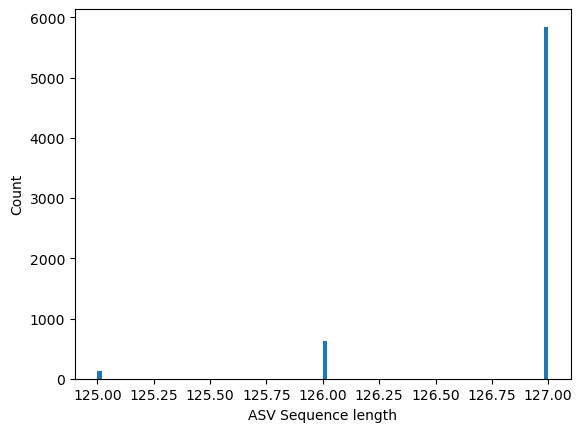

In [12]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print(MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Pre-compute embeddings.

Use pre-trained embeddings to pre-generate tensors for each ASV sequence.

In [13]:
""" Generic embedding wrapper class """
class GenomeEmbedding:
    def embed_sequence(self, x: str) -> Tensor:
        raise NotImplementedError()

    def embed_batch(self, strs: List[str]) -> Tensor:
        raise NotImplementedError()
        
    def embed_empty_sequence(self) -> Tensor:
        raise NotImplementedError()


""" Fallback name for 'empty' ASV """
EMPTY_ASV_ID = "<EMPTY_ASV>"


""" Function to pre-embed ASVs into a file. """
def precompute_embeddings(create_embed_model: Callable[[], GenomeEmbedding], output_file: Path, batch_size: int = 50, **embed_kwargs):
    """
    :return: The embedding of the "empty" ASV (aka the 'padding embedding').
    """
    if output_file.exists():
        print(f"Embeddings already exist: {output_file}")
        with h5py.File(output_file, "r") as f:
            padding_embedding = f[EMPTY_ASV_ID][:]  # Load the padding embedding.
            print(f"[*] Example: {EMPTY_ASV_ID} -> Tensor of shape {padding_embedding.shape}")
    else:
        embedding_model = create_embed_model()
        padding_embedding =  embedding_model.embed_empty_sequence().cpu().float().numpy()
        print("Got padding embedding of shape {}".format(padding_embedding.shape))

        _asv_id_subset_list = list(asv_seqs_subset.keys())
        pbar = tqdm(total=len(_asv_id_subset_list))
        with h5py.File(output_file, 'w') as f:
            # First, save padding embedding.
            f.create_dataset(EMPTY_ASV_ID, data=padding_embedding, compression='lzf')
    
            # Next, embed the ASV sequences.
            for i in range(0, len(_asv_id_subset_list), batch_size):  # compute embedding in batches.
                asv_id_batch = _asv_id_subset_list[i:i+batch_size]
                asv_seq_batch = [asv_seqs_subset[asv_id] for asv_id in asv_id_batch]
                batch_embeddings = embedding_model.embed_batch(asv_seq_batch, **embed_kwargs).cpu().float().numpy()  # shape (batch_len, 4096)
                for asv_id, asv_embedding in zip(asv_id_batch, batch_embeddings):  # each ASV_ID gets its own entry.
                    f.create_dataset(asv_id, data=asv_embedding, compression='lzf')
            
                gc.collect()
                torch.cuda.empty_cache()
                pbar.update(len(asv_id_batch))
    
        print("Done. performing cleanup.")
        del embedding_model
        gc.collect()
        torch.cuda.empty_cache()

## Evo model

### Model wrappers.

In [14]:
class EvoWrapper(GenomeEmbedding):
    def __init__(
        self, 
        device: str = 'cuda:0',
    ):
        evo_model = Evo('evo-1-131k-base')
        model, tokenizer = evo_model.model, evo_model.tokenizer
        
        ### not needed, StripedHyena already in bfloat16 mode for weights.
        # if half_precision:  
        #     # Use half precision (13GB instead of 26GB)    
        #     print("using half precision")
        #     model = model.half()
        
        if device.startswith("cuda"):
            assert torch.cuda.is_available(), "CUDA is unavailable!"
            torch.cuda.empty_cache()

        model.to(device)
        model.eval()  # huggingface spec: switch to evaluation mode
        self.device = device
        self.striped_hyena_model = model

        n_layers = len(self.striped_hyena_model.blocks)
        print("[evo] Loaded Hyena Model which has {} blocks.".format(n_layers))
        self.tokenizer = tokenizer

    def tokenize_single(self, sequence: str, max_seq_length: Optional[int] = None) -> Tensor:
        tokenized_ids = self.tokenizer.tokenize(sequence)
        if max_seq_length is not None:
            tokenized_ids += [self.tokenizer.pad_id] * (max_seq_length - len(sequence))
        return tokenized_ids

    def run_hyena(self, input_ids: Tensor) -> Tensor:
        with torch.no_grad():
            x = self.striped_hyena_model.embedding_layer.embed(input_ids)
            """
            TODO: Simply calling stateless_forward() outputs a "final" tensor which (modulo a final RMSNorm() layer) is supposed to represent the next-token-prediction logits.
            It might be best to call all layers except for the final one.

            # original code:
            # x, _ = self.striped_hyena_model.stateless_forward(x)  # todo: figure out if padding is required for this context.
            """
            for _, block in enumerate(self.striped_hyena_model.blocks[:-1]):  # all but last layer.
                """
                Note: padding_mask is not required here; the evo model is autoregressive.
                This means that the embedding of ("A") is always the prefix of the embedding ("AC"). 
                Equal up to bfloat16 precision, of course.
                """
                x, _ = block(x, inference_params=None, padding_mask=None)
            
            return x

    def embed_sequence(self, nucleotides: str, max_seq_length: Optional[int] = None) -> Tensor:
        input_ids = self.tokenize_single(x, max_seq_length=max_seq_length)
        input_ids = torch.tensor(tokenized, dtype=torch.int)
        input_ids = input_ids.to(self.device).unsqueeze(0)
        seq_len = len(nucleotides)
        return self.run_hyena(input_ids)[0, seq_len-1, :]  # Note: the "-1" here indicates the indexing of the particular slice UP TO the last character of the sequence.
        

    def embed_batch(self, seqs: List[str], max_seq_length: Optional[int] = None) -> Tensor:
        input_ids = torch.tensor(
            [
                self.tokenize_single(x, max_seq_length=max_seq_length)
                for x in seqs
            ],
            dtype=torch.int
        ).to(self.device)
        hyena_output = self.run_hyena(input_ids)

        return torch.stack([
            seq_hyena_output[len(seq)-1, :]
            for seq, seq_hyena_output in zip(seqs, hyena_output)
        ], axis=0)

    def embed_empty_sequence(self) -> Tensor:
        input_ids = torch.tensor([np.uint8(self.tokenizer.eos)], dtype=torch.int)  # length 1 of "EOS" id.
        input_ids = input_ids.to(self.device).unsqueeze(0)
        return self.run_hyena(input_ids)[0, 0, :]  # Note: the "-1" here indicates the indexing of the particular slice UP TO the last character of the sequence.

### Evo: Compute embedding in batches.

This cell also loads/computes the "padding" embedding.

In [15]:
EVO_EMBEDDING_FILE = NOTEBOOK_CACHE / 'embeddings.evo.h5'
precompute_embeddings(
    lambda: EvoWrapper('cuda:0'), 
    EVO_EMBEDDING_FILE, 
    batch_size=50, 
    max_seq_length=MAX_ASV_SEQUENCE_LEN,
)

Embeddings already exist: __tmp/american_gut_USCA/embeddings.evo.h5
[*] Example: <EMPTY_ASV> -> Tensor of shape (4096,)


## DNABert model

In [16]:
# """ Minor test: does padding affect the embedding? --> Answer: it doesn't. Uncomment and run this cell to verify. """

# tokenizer = AutoTokenizer.from_pretrained("quietflamingo/dnaberts-no-flashattention", trust_remote_code=True)
# model = AutoModel.from_pretrained("quietflamingo/dnaberts-no-flashattention", trust_remote_code=True)

# ### Question: is "ACGT<PADDING>" embedding the same as "ACGT" embedding?
# dna = "ACGT"
# dna_longer = "ACGTAGTCAGTGGGGGGG"  # force padding on the first sequence "ACGT"

# short_input = tokenizer([dna], return_tensors = 'pt')
# print("short input for ACGT:", short_input['input_ids'][0], "-->", tokenizer.decode(short_input['input_ids'][0]))
# long_input = tokenizer([dna, dna_longer], return_tensors = 'pt', padding=True)
# print("padded input for ACGT:", long_input['input_ids'][0], "-->", tokenizer.decode(long_input['input_ids'][0]))  ## adds 2 padding

# print("short output shape: {}".format(model(**short_input)[0].shape))
# assert torch.allclose(
#     input=model(**short_input)[0][0, 0],
#     other=model(**long_input)[0][0, 0],
# )

### Model wrappers.

In [17]:
def kwargs_torch_convert_device(kwargs_dict: Dict) -> Dict:
    dict_copy = dict()
    for k, v in kwargs_dict.items():
        if isinstance(v, Tensor):
            v = v.to("cuda")
        dict_copy[k] = v
    return dict_copy
    

class DNABertSWrapper(GenomeEmbedding):
    def __init__(
        self, 
        device: str = 'cuda:0',
    ):
        """ Constructor for the wrapper. """
        """ 
        Note: the official "DNABERT-*" model hosted by author zhihan1996 won't work in newer environments, due to its dependency on an older version of triton package (triton-2.0.0). 
        Evo/Hyena uses newer FlashAttention+Triton, so for this model we must use a version without the older FlashAttention.
        """
        tokenizer = AutoTokenizer.from_pretrained("quietflamingo/dnaberts-no-flashattention", trust_remote_code=True)
        model = AutoModel.from_pretrained("quietflamingo/dnaberts-no-flashattention", trust_remote_code=True)

        print("[DNABert] Special tokens:")
        for name, token in tokenizer.special_tokens_map.items():
            print(f"  {name}: {token} (ID: {tokenizer.convert_tokens_to_ids(token)})")
        
        if device.startswith("cuda"):
            assert torch.cuda.is_available(), "CUDA is unavailable!"
            torch.cuda.empty_cache()

        model.to(device)
        model.eval()
        self.device = device
        self.model = model
        self.tokenizer = tokenizer

        # self.pad_id = tokenizer.convert_tokens_to_ids(tokenizer.pad_token)  # added whenever padding is required.
        # self.sep_id = tokenizer.convert_tokens_to_ids(tokenizer.sep_token)  # added at the end of each sequence.

    def embed_sequence(self, x: str) -> Tensor:
        """ 
        Note: the DNABert-S tokenizer automatically adds a "CLS" classification token at the start. 
        This means that after running the model, the first slice contains the info needed for downstream classification tasks from the entire sequence input. 
        """
        model_input = self.tokenizer(x, return_tensors='pt')
        with torch.no_grad():
            model_output, _ = self.model(**kwargs_torch_convert_device(model_input))  # shape (1, n_tokens, embed_dim=768)
            return model_output[0, 0]  # output of shape 768, obtained by taking the first slice (see note above)

    def embed_batch(self, seqs: List[str], max_seq_length: Optional[int] = None) -> Tensor:
        model_input = self.tokenizer(seqs, return_tensors = 'pt', padding=True)
        with torch.no_grad():
            model_output, _ = self.model(**kwargs_torch_convert_device(model_input))  # shape (n_seqs, n_tokens, embed_dim=768). Note that **model_input handles the padding masks automatically.
            return model_output[:, 0, :]  # output of shape (n_seqs, 768), obtained by taking the first slice for each seq (see note above)

    def embed_empty_sequence(self) -> Tensor:
        """
        Embed the empty sequence "", which auto-tokenizers to [CLS] [SEP].
        """
        return self.embed_sequence("")

### DNABert: Embed in batches.

In [18]:
DNABERT_S_EMBEDDING_FILE = NOTEBOOK_CACHE / 'embeddings.dnabert-s.h5'
precompute_embeddings(
    lambda: DNABertSWrapper('cuda:0'), 
    DNABERT_S_EMBEDDING_FILE, 
    batch_size=100, 
    max_seq_length=MAX_ASV_SEQUENCE_LEN,
)

Embeddings already exist: __tmp/american_gut_USCA/embeddings.dnabert-s.h5
[*] Example: <EMPTY_ASV> -> Tensor of shape (768,)


# Dataset: Train-test split.

Create "train" and "test" pandas dataframes. These dataframes will be converted to torch tensors at a later time.

In [19]:
""" Option 1: Train: US, Test: CA """

train_df = sample_subset.loc[sample_subset['iso'] == 'US']
test_df = sample_subset.loc[sample_subset['iso'] == 'CA']
print("# train samples: {}".format(train_df.shape[0]))
print("# test samples: {}".format(test_df.shape[0]))

# train samples: 1189
# test samples: 118


In [20]:
""" Option 2: Random test/train split. """
from sklearn.model_selection import train_test_split
TRAIN_TEST_SPLIT_RNG_SEED=31415  # for reproducibility.


# """ Invoke train-test split function from sklearn. """
# train_df, test_df = train_test_split(
#     sample_metadata_valid_regions, 
#     test_size=0.2,  # or whatever fraction you want for test
#     stratify=sample_metadata_valid_regions['iso'],  # stratify by geographical region, so each region maintains their proportionality.
#     random_state=TRAIN_TEST_SPLIT_RNG_SEED,  # for reproducibility
# )

# Functions to prepare for training loop. 

NEW IMPL:
1. `MicrobiomeDataset` --- implementation of torch's Dataset
2. `MicrobiomeDataLoader` --- implementation of torch's DataLoader for fast parallel loading and memory pinning.
3. `main_training_loop()` -- The training loop for a generic model (using KL loss).

OLD IMPL:
1. `get_dataset_tensors()` -- Conversion of dataset into numeric arrays.
2. `batchify_dataframe()` -- Randomly divide up a dataframe into batches.
3. `main_training_loop()` -- The training loop for a generic model (using KL loss).

In [21]:
class MicrobiomeSampleEmbedding:
    def __init__(
        self, 
        embedding_file: Path, 
        asv_id_subset: Optional[set] = None, 
        cache_embeddings: bool = False,
        tensor_dtype = torch.float32
    ):
        self.embedding_file = embedding_file
        self.asv_id_subset = asv_id_subset
        self.dtype = tensor_dtype

        with h5py.File(self.embedding_file, "r") as h5_file:
            self.padding_embedding = torch.tensor(h5_file[EMPTY_ASV_ID][:], dtype=self.dtype)
            print("Loading tensor embeddings from {} (genome embedding shape = {})".format(
                self.embedding_file,
                self.padding_embedding.shape,
            ))

        self.cache_embeddings = cache_embeddings
        self.embedding_cache = {}
        if cache_embeddings:
            self._cache_all_embeddings()
    
    def _cache_all_embeddings(self):
        """
        Load all embeddings into memory for faster access.
        Warning: This can use significant RAM for large embedding files.
        """
        print("Caching embeddings in memory...")
        with h5py.File(self.embedding_file, "r") as f:
            for key in f.keys():
                if self.asv_id_subset is None or key in self.asv_id_subset:
                    embedding = f[key][:]
                    self.embedding_cache[key] = torch.tensor(embedding, dtype=self.dtype)
                    embedding_dim = np.size(embedding)
        print(f"Cached {len(self.embedding_cache)} embeddings in memory.")

    def convert(self, sample: MicrobiomeSample, max_num_asvs: int) -> Tuple[List[str], Tensor, Tensor, Tensor]:
        # Initialize tensors with padding
        features = self.padding_embedding.unsqueeze(0).repeat(max_num_asvs, 1)
        targets = torch.zeros(max_num_asvs, dtype=self.padding_embedding.dtype)
        padding_mask = torch.zeros(max_num_asvs, dtype=torch.bool)
        
        # Get ASV data for this sample
        asv_ids, abunds = sample.relative_abundance_array(asv_id_subset=self.asv_id_subset)
        
        # Limit to max_num_asvs
        asv_ids = asv_ids[:max_num_asvs]
        abunds = abunds[:max_num_asvs]
        
        # Fill in the tensors
        if self.cache_embeddings:
            # Use cached embeddings
            for asv_idx, asv_id in enumerate(asv_ids):
                if asv_id not in self.embedding_cache:
                    raise KeyError(f"ASV ID '{asv_id}' not found in cache, loaded from '{self.embedding_file}'. Was it pre-computed properly?")
                features[asv_idx] = self.embedding_cache[asv_id]
        else:
            # Load embeddings from file
            with h5py.File(self.embedding_file, "r") as h5_file:
                for asv_idx, asv_id in enumerate(asv_ids):
                    if asv_id not in h5_file:
                        raise KeyError(f"ASV ID '{asv_id}' not found in embeddings file '{self.embedding_file}'.")
                    features[asv_idx] = torch.tensor(h5_file[asv_id][:], dtype=self.dtype)
        
        # Set abundance targets & padding
        targets[:len(asv_ids)] = torch.tensor(abunds, dtype=targets.dtype)
        padding_mask[:len(asv_ids)] = True  # "1" indicates actual ASVs and "0" indicates empty ASVs that we shouldn't use in the computation/gradients.
        return asv_ids, features, targets, padding_mask


class MicrobiomeDataset(Dataset):
    """
    PyTorch Dataset for microbiome data with ASV embeddings and abundance values.
    """
    
    def __init__(
        self, 
        df: pd.DataFrame, 
        embedding_file: str,
        max_num_asvs: int,
        asv_id_subset: Optional[set] = None,
        cache_embeddings: bool = False
    ):
        """
        Initialize the microbiome dataset.
        
        :param df: DataFrame with columns ['project', 'srs', ...] containing sample metadata
        :param embedding_file: Path to HDF5 file containing ASV embeddings
        :param max_num_asvs: Maximum number of ASVs per sample
        :param asv_id_subset: Optional subset of ASV IDs to consider
        :param cache_embeddings: If True, load all embeddings into memory (faster but uses more RAM)
        """
        self.df = df.reset_index(drop=True)
        self.sample_mapping = MicrobiomeSampleEmbedding(embedding_file, asv_id_subset, cache_embeddings, tensor_dtype=torch.float32)
        self.max_num_asvs = max_num_asvs
        
        # Pre-process the data to create a mapping from index to sample info
        self.samples: List[MicrobiomeSample] = self.initialize_samples()
        self.sample_indices = {sample.sample_id: i for i, sample in enumerate(self.samples)}
    
    def initialize_samples(self):
        """
        Create a mapping from dataset index to (project_id, sample_id, row_index).
        This allows efficient random access without groupby operations.
        """
        sample_list = []
        for proj_id, proj_section in self.df.groupby("project"):
            proj = MicrobiomeProject(proj_id)
            target_sample_ids = set(proj_section['srs'])  # subset of samples from this project that we want to keep.
            for sample in proj.samples:
                if sample.sample_id in target_sample_ids:
                    sample_list.append(sample)

        assert len(sample_list) == self.df.shape[0], "Dataframe specified {} samples, but ended up with {} instead.".format(self.df.shape[0], len(sample_list))
        # Finally, sort sample_list according to dataframe ordering.
        sample_ordering = {row['srs']: row_idx for row_idx, row in self.df.iterrows()}
        sample_list = sorted(sample_list, key=lambda samp: sample_ordering[samp.sample_id])
        return sample_list
    
    def __len__(self) -> int:
        return len(self.samples)

    def retrieve_by_id(self, sample_id: str) -> Tuple[List[str], Tensor, Tensor, Tensor]:
        if sample_id in self.sample_indices:
            sample_idx = self.sample_indices[sample_id]
            return self.__getitem__(sample_idx)
        else:
            raise KeyError(f"Sample ID '{sample_id}' not found in this dataset.")
    
    def __getitem__(self, idx: int) -> Tuple[List[str], Tensor, Tensor, Tensor]:
        """
        Get a single sample by index.
        
        :param idx: Index of the sample
        :return: Tuple of (asv_ids, features, targets)
            - asv_ids: List of ASV IDs in this sample
            - features: Tensor of shape (max_num_asvs, embedding_dim) with ASV embeddings
            - targets: Tensor of shape (max_num_asvs,) with abundance values
        """
        return self.sample_mapping.convert(self.samples[idx], self.max_num_asvs)


# ## =========== Test the above code.
# _dataset = MicrobiomeDataset(
#     test_df, EVO_EMBEDDING_FILE, MAX_NUM_ASVS,
#     asv_id_subset=asv_id_subset,
#     cache_embeddings=False
# )
# _asvs, _feats, _targets = _dataset[0]
# print("[*] ASVs:")
# print("\t",_asvs)
# print("[*] features:")
# print(_feats.shape)
# print("[*] predictor targets:")
# print(_targets.shape)


# del _dataset
# del _asvs
# del _feats
# del _targets
# _ = gc.collect()

In [22]:
def collate_microbiome_batch(
    batch: List[Tuple[List[str], Tensor, Tensor, Tensor]]
) -> Tuple[List[List[str]], Tensor, Tensor, Tensor]:
    """
    Custom collate function for microbiome data.
    
    :param batch: List of (asv_ids, features, targets) tuples
    :return: Batched (asv_ids_list, features_batch, targets_batch)
    """
    asv_ids_list, features_list, targets_list, padding_masks_list = zip(*batch)
    
    # Stack the tensors
    features_batch = torch.stack(features_list, dim=0)  # (batch_size, max_num_asvs, embedding_dim)
    targets_batch = torch.stack(targets_list, dim=0)    # (batch_size, max_num_asvs)
    padding_masks_batch = torch.stack(padding_masks_list, dim=0)
    
    return list(asv_ids_list), features_batch, targets_batch, padding_masks_batch


class MicrobiomeDataLoader(DataLoader):
    """
    Wrapper class for microbiome DataLoader with additional functionality.
    """
    
    def __init__(self, 
                 df: pd.DataFrame,
                 embedding_file: str,
                 max_num_asvs: int,
                 batch_size: int = 32,
                 shuffle: bool = True,
                 num_workers: int = 0,
                 pin_memory: bool = False,
                 asv_id_subset: Optional[set] = None,
                 cache_embeddings: bool = False,
                 **dataloader_kwargs):
        """
        Initialize the microbiome data loader.
        
        :param df: DataFrame with sample metadata
        :param embedding_file: Path to HDF5 embedding file
        :param max_num_asvs: Maximum ASVs per sample
        :param batch_size: Batch size
        :param shuffle: Whether to shuffle data
        :param num_workers: Number of worker processes
        :param pin_memory: Whether to pin memory
        :param asv_id_subset: Optional ASV ID subset
        :param cache_embeddings: Whether to cache embeddings
        :param dataloader_kwargs: Additional DataLoader arguments
        """
        # Create dataset
        dataset = MicrobiomeDataset(
            df=df,
            embedding_file=embedding_file,
            max_num_asvs=max_num_asvs,
            asv_id_subset=asv_id_subset,
            cache_embeddings=cache_embeddings
        )
        super().__init__(
            dataset=dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory,
            collate_fn=collate_microbiome_batch,
            **dataloader_kwargs
        )

In [23]:
def main_training_loop(
    model: nn.Module, 
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    train_df: pd.DataFrame, 
    test_df: pd.DataFrame, 
    embedding_file: Path,
    num_workers: Optional[int] = 0,
    batch_size: int = 5,
    num_epochs: int = 5000, 
    print_progress: bool = True, 
    print_every: int = 50, 
    plot_history: bool = False, 
    manual_gc: bool = True,
    rng_seed: int = 314159,
):
    """
    Train an input model on the given dataset. Uses torch.optim.Adam by default.
    This function's training loop mutates the parameters of the `model` object.
    
    :param model: The model to train. Should be designed to take a tensor of shape (*, MAX_NUM_ASVS, ASV_EMBED_DIM) as input, and output (*, MAX_NUM_ASVS) which represents a batched vector of logits.
    :param optimizer: The torch.optim.Optimizer instance used to optimize.
    :param train_df: The dataframe that specifies the training dataset.
    :param test_df: The dataframe that specifies the test dataset.
    :param num_workers: Specify the number of workers to load data in parallel. Note that a separate dataloader is created for train/test; so if both are provided the actual # of workers is 2 times the specified value.
    :param batch_size: The size of each batch.
    :param batch_seed: The RNG seed for randomly batching. Used for reprocibility.
    :param num_epochs: The total number of epochs to train. (1 epoch is a full pass on the entire training dataset, after batching.)
    :param print_progress: Indicate whether to print loss values periodically to stdout. Specify `print_every` to change how often this occurs.
    :param print_every: Indicate how often to print progress as a debug message to stdout. Only relevant if `print_progress` is set to true.
    :param plot_history: Indicate whether to plot the training loss/test loss history. Test loss is only plotted if test_df is provided.
    :param manual_gc: Indicate whether to invoke gc.collect() and torch.cuda.empty_cache() after every batch. (default=True)
    :param rng_seed: The random generator seed to use for training. Specify for reproducibility. (default: 314159)
    """

    """ Initialization. """
    epoch_history = []
    training_loss_history = []
    test_loss_history = []
    
    """ Initialize dataset objects. """
    def _seed_worker(worker_id):
        worker_seed = worker_id + rng_seed
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    train_rng = torch.Generator()
    train_rng.manual_seed(rng_seed)
    train_dloader = MicrobiomeDataLoader(
        train_df, embedding_file, MAX_NUM_ASVS, batch_size,
        shuffle=True, num_workers=num_workers, pin_memory=True,
        asv_id_subset=asv_id_subset,
        cache_embeddings=True,
        generator=train_rng, worker_init_fn=_seed_worker, drop_last=True,
    )
    print(f"Training dataset size: {len(train_dloader.dataset)}")
    print(f"Number of training batches: {len(train_dloader)}")
    
    test_dloader = MicrobiomeDataLoader(
        test_df, embedding_file, MAX_NUM_ASVS, batch_size,
        shuffle=True, num_workers=num_workers, pin_memory=True,
        asv_id_subset=asv_id_subset,
        cache_embeddings=True,
    )
    print(f"Test dataset size: {len(test_dloader.dataset)}")
    print(f"Number of test batches: {len(test_dloader)}")

    def __do_gc():
        if manual_gc:
            gc.collect()
            torch.cuda.empty_cache()
        else:
            pass

    """ Training loop -- Optimize using batches. """
    def _compute_test_loss() -> float:
        total_test_loss = 0.0
        model.eval()
        with torch.no_grad():
            for batch_idx, (test_asv_id_list, test_batch_features, test_y, test_padding_mask) in enumerate(test_dloader):
                num_unmasked_genomes = test_padding_mask.sum(axis=-1)
                num_asvs = torch.tensor([len(asvs) for asvs in test_asv_id_list], dtype=int)
                assert (num_unmasked_genomes == num_asvs).all(), f"In training batch {batch_idx}, expected # of asvs to be {num_asvs}, but got {num_unmasked_genomes} True values in mask."
            
                test_y_hat = model(
                    test_batch_features.cuda(non_blocking=True), 
                    test_padding_mask.cuda(non_blocking=True)
                )
                
                assert test_y_hat.shape == test_padding_mask.shape, f"Neural Network output and mask have different shapes: {test_y_hat.shape} (NN) vs {test_padding_mask.shape} (mask)"
                total_test_loss += loss_fn(
                    nn.functional.log_softmax(test_y_hat, dim=-1),     # log pred probabilities
                    torch.log(test_y.cuda(non_blocking=True))   # log target probabilities
                ).item() * test_y.shape[0]

                # clear some space for next batch.
                del test_y_hat
                __do_gc()
        return total_test_loss / len(test_dloader.dataset)  # divide by total dataset size.

    print(f"Initial Test Loss: {_compute_test_loss()}")

    for epoch in tqdm(range(num_epochs)):
        epoch_training_loss = 0.0
        for batch_idx, (training_asv_id_list, training_batch_features, training_y, training_padding_mask) in enumerate(train_dloader):
            num_unmasked_genomes = training_padding_mask.sum(axis=-1)
            num_asvs = torch.tensor([len(asvs) for asvs in training_asv_id_list], dtype=int)
            assert (num_unmasked_genomes == num_asvs).all(), f"In training batch {batch_idx}, expected # of asvs to be {num_asvs}, but got {num_unmasked_genomes} True values in mask."
            
            # print(f"Got batch {batch_idx}")
            model.train()
            optimizer.zero_grad()
            
            # print("doing inference.")
            training_y_hat = model(
                training_batch_features.cuda(non_blocking=True), 
                training_padding_mask.cuda(non_blocking=True)
            )

            # print("computing loss.")
            assert training_y_hat.shape == training_padding_mask.shape, f"Neural Network output and mask have different shapes: {training_y_hat.shape} (NN) vs {training_padding_mask.shape} (mask)"
            training_loss = loss_fn(
                nn.functional.log_softmax(training_y_hat, dim=-1),          # log pred probabilities
                torch.log(training_y.cuda(non_blocking=True))        # log target probabilities
            )

            # print("computing gradients.")
            training_loss.backward()

            # print("invoking optimizer.step().")
            optimizer.step()

            # print("cleaning up.")
            epoch_training_loss += training_loss.item() * training_y.shape[0]

            # clear some space for next batch.
            del training_y_hat
            del training_loss
            __do_gc()
        epoch_training_loss /= len(train_dloader.dataset)

        # option implementation
        if epoch % print_every == 0:
            """ Evaluate test loss. """
            epoch_test_loss = _compute_test_loss()
                
            if print_progress:
                print(f"Epoch {epoch} | Training Loss: {epoch_training_loss} | Test Loss: {epoch_test_loss}")

            if plot_history:
                epoch_history.append(epoch)
                training_loss_history.append(epoch_training_loss)
                test_loss_history.append(epoch_test_loss)

    if plot_history:
        fig, ax = plt.subplots(1, 1)
        ax.plot(epoch_history, training_loss_history, color='red', label='train')
        ax.plot(epoch_history, test_loss_history, color='green', label='test')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        plt.legend()

# Transformer-like model
## Model definition.

Create the following model:

In [24]:
class SumAlongDim(nn.Module):
    def __init__(self, dim, keepdim=False):
        super().__init__()
        self.dim = dim
        self.keepdim = keepdim

    def forward(self, x) -> Tensor:
        return x.sum(dim=self.dim, keepdim=self.keepdim)


class MatrixConcatBroadcastFFN(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, init_rng: Optional[torch.Generator] = None):
        """
        A model which takes as input two tensors:
        - `A` of shape (*, G, G)
        - `B` of shape (*, embed_dim).
        This module implemented the broadcasted concatenation of B onto A, producing a tensor of shape (*, G, G, 1+embed_dim); B[*] is broadcasted into every entry A[*,i,j].
        Then, this is passed into a feedforward network taking a (*, G, G, 1+embed_dim) as input, and outputting a (*, G, G, 1) tensor. 
        The last dim is squeezed, producing an output of shape (*, G, G).
        """
        super().__init__()
        self.linear_A = nn.Linear(1, hidden_dim)
        self.linear_B = nn.Linear(embed_dim, hidden_dim)
        self.activation = nn.GELU()
        self.final_linear = nn.Linear(hidden_dim, 1)
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, A: Tensor, B: Tensor) -> Tensor:
        # A: (*, G, G)
        # B: (*, embed_dim)
        A_proj = self.linear_A(A.unsqueeze(-1))                  # (*, G, G, hidden_dim)
        B_proj = self.linear_B(B).unsqueeze(-2).unsqueeze(-2)    # (*, 1, 1, hidden_dim)
        y = self.activation(A_proj + B_proj)                           # (*, G, G, hidden_dim)
        y = self.final_linear(y).squeeze(-1)                     # (*, G, G)
        return y


class MultiHeadSetPool(nn.Module):
    def __init__(
        self, 
        genome_dim: int,
        num_heads: int,
        out_dim_per_head: int,
        init_rng: Optional[torch.Generator] = None
    ):
        super().__init__()
        self.linear = nn.Linear(genome_dim, num_heads * out_dim_per_head)
        self.activation1 = nn.GELU()
        self.unflatten = nn.Unflatten(
            dim=-1, unflattened_size=[num_heads, out_dim_per_head]
        )
        self.pool = SumAlongDim(dim=-3, keepdim=False)
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, g: Tensor, genome_padding_mask: Tensor):
        """ 
        :param g: A float tensor of shape (B, G, genome_dim).
        :param genome_padding_mask: a boolean tensor of shape (B, G). Value [i,j] is "true" if the batch i, genome j is a non-empty ASV/organism.
        """
        assert len(genome_padding_mask.shape) == 2          # TODO: remove assertion after debugging.
        assert g.shape[0] == genome_padding_mask.shape[0]   # TODO: remove assertion after debugging.
        assert g.shape[1] == genome_padding_mask.shape[1]   # TODO: remove assertion after debugging.
        
        # Let D = out_dim_per_head, H=# heads.
        y = self.linear(g)       # shape (n_batch=B, n_genomes=G, H*D); per-genome operation.
        y = self.activation1(y)  # shape (B, G, H*D); element-by-element operation
        y = y * genome_padding_mask.unsqueeze(-1)   # Zero-out all genomes that are "empty genomes" (a.k.a. "padding")
        y = self.unflatten(y)    # shape (B, G, H, D); per-genome operation.
        y = self.pool(y)         # shape (B, H, D); "G" gets summed out.
        return y


class MultiHeadUnit(nn.Module):
    def __init__(
        self, 
        model_dim: int, 
        genome_dim: int, 
        num_heads: int, 
        key_query_dim: int, 
        latent_collection_dim: int, 
        combination_latent_dim: int,
        init_rng: Optional[torch.Generator] = None
    ):
        """
        Module which implements the multi-head unit described above.
        """
        super().__init__()
        
        # This computes the "set collection" transformation.
        self.collection_pool = MultiHeadSetPool(genome_dim, num_heads, latent_collection_dim, init_rng)

        self.key_proj = nn.Sequential(
            nn.Linear(genome_dim, num_heads * key_query_dim),
            nn.Unflatten(dim=-1, unflattened_size=[num_heads, key_query_dim])
        )
        self.query_proj = nn.Sequential(
            nn.Linear(model_dim, num_heads * key_query_dim),
            nn.Unflatten(dim=-1, unflattened_size=[num_heads, key_query_dim])
        )
        self.norm_const = 1 / float(np.sqrt(key_query_dim))
        self.kq_activation = nn.GELU()
        self.combination = MatrixConcatBroadcastFFN(
            embed_dim=latent_collection_dim, hidden_dim=combination_latent_dim,
            init_rng=init_rng
        )
        self.head_linear = nn.Linear(num_heads, model_dim)               # shape (B, G, model_dim)        
        
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: Tensor, g: Tensor, genome_padding_mask: Tensor):
        """
        Generally, the inputs are expected to have the following shapes:
            - x: (n_batch, n_genomes, model_dim)
            - g: (n_batch, n_genomes, genome_dim)
            - genome_padding_mask: (n_batch, n_genomes) boolean tensor
        """
        assert len(g.shape) == 3                                                                         # TODO: remove assertion after debugging.
        assert len(x.shape) == 3                                                                         # TODO: remove assertion after debugging.
        assert x.shape[0] == g.shape[0], f"# of batches do not match. x: {x.shape[0]}, g: {g.shape[0]}"  # TODO: remove assertion after debugging.
        assert x.shape[1] == g.shape[1], f"# of genomes do not match. x: {x.shape[1]}, g: {g.shape[1]}"  # TODO: remove assertion after debugging.

        c = self.collection_pool(g, genome_padding_mask)   # Combintes genomes & permutation-invariant; ZEROES-out "empty genomes" using masks. Shape (B, H, latent_collection_dim)
        k = self.key_proj(g)                   # Operaters per-genome. Shape (B, G, H, key_query_dim); permutation-respecting along n_genomes dimension; e.g. key_proj(perm(g)) = perm(key_proj(g))
        q = self.query_proj(x)                 # Operaters per-genome. Shape (B, G, H, key_query_dim); permutation-respecting along n_genomes dimension; e.g. query_proj(perm(g)) = perm(query_proj(g))

        # kq: permutation-respecting along both n_genomes dimensions.
        kq = self.norm_const * torch.matmul(k.permute(0, 2, 1, 3), q.permute(0, 2, 3, 1))  # shape (B, H, G, G)  -> Computes the key-query combination for each pair of genomes, per head. rows are indexed by key genome and columns indexed by query "x".
        kq = self.kq_activation(kq)      # shape (B, H, G, G)

        y = self.combination(kq, c)      # shape (B, H, G, G)

        # apply masking.
        # Expand m for broadcasting to target positions i and j.
        mask_i = genome_padding_mask.unsqueeze(2)  # shape (B, G, 1)
        mask_j = genome_padding_mask.unsqueeze(1)  # shape (B, 1, G)
        mask_ij = mask_i & mask_j                  # shape (B, G, G)
        mask_ij = mask_ij.unsqueeze(1)             # shape (B, 1, G, G)

        y = y * mask_ij                  # shape (B, H, G, G), but entries (batch, head, i, j) have been zeroed out if mask[batch, i] == 0 or mask[batch, j] == 0.
        y = y.sum(dim=-1)                # shape (B, H, G)
        y = y.permute(0, 2, 1)           # shape (B, G, H)
        y = self.head_linear(y)          # shape (B, G, model_dim)
        return y


class ModelBlock(nn.Module):
    def __init__(
        self, 
        model_dim: int, 
        genome_dim: int, 
        num_heads: int, 
        key_query_dim: int, 
        latent_collection_dim: int, 
        combination_latent_dim: int,
        residual_scale: float = 0.1,
        init_rng: Optional[torch.Generator] = None
    ):
        super().__init__()
        self.unit = MultiHeadUnit(
            model_dim, genome_dim, num_heads, key_query_dim, latent_collection_dim, combination_latent_dim,
            init_rng=init_rng
        )
        self.feedforward = nn.Sequential(
            nn.Linear(model_dim, model_dim),
            nn.GELU(),
            nn.Linear(model_dim, model_dim)
        )
        
        self.layer_norm1 = nn.LayerNorm(model_dim)
        self.layer_norm2 = nn.LayerNorm(model_dim)
        self.residual_scale = residual_scale
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: Tensor, g: Tensor, genome_padding_mask: Tensor) -> Tensor:
        # Note: since most operations here are per-genome, padding_mask need not be applied explicitly. We pass that responsibility into the succeeding layers that come after this block.
        # The only exception is the MultiHeadUnit, so we also pass the responsibility of masking onto that layer.
        residual1 = x
        x = self.layer_norm1(x)                      # operates per-genome
        x = self.unit(x, g, genome_padding_mask)     # permutation-invariant.
        x = residual1 + self.residual_scale * x      # operates per-genome (residual connection for gradient stability)
        
        residual2 = x
        x = self.layer_norm2(x)                      # operates per-genome
        x = self.feedforward(x)                      # operates per-genome
        x = residual2 + self.residual_scale * x      # operates per-genome (residual connection for gradient stability)
        
        return x


class AbundancePredictionModel(nn.Module):
    def __init__(
        self,
        n_layers: int,
        model_dim: int,
        genome_dim: int, 
        num_heads: int, 
        key_query_dim: int, 
        latent_collection_dim: int, 
        combination_latent_dim: int,
        init_rng: Optional[torch.Generator] = None
    ):
        """
        :param n_layers: the number of permutation-invariant attention blocks.
        :param model_dim: the latent input-output embedding dimension of the attention blocks.
        :param genome_dim: the input genome embedding dimension.
        :param num_heads: the number of attention heads.
        :param key_query_dim: the attention d_key, d_query, set equal to each other.
        :param latent_collection_dim: the dimension of the latent embedding of the set-combination.
        :param combination_latent_dim: the "hidden unit" dimension of the feedforward network that combines the Key-Query products & the collection.
        :param init_rng: A seeded torch.Generator instance for reproducibility of layer weight initializations.
        """
        super().__init__()
        self.model_dim = model_dim
        self.initial_linear = nn.Linear(genome_dim, model_dim)  # shape (n_batch=B, n_genomes=G, model_dim)
        self.blocks = nn.ModuleList([
            ModelBlock(
                model_dim, genome_dim, num_heads, key_query_dim, latent_collection_dim, combination_latent_dim, 
                init_rng=init_rng
            )  # shape (B, G, model_dim)
            for _ in range(n_layers)
        ])
        
        # Add final layer norm
        self.final_layer_norm = nn.LayerNorm(model_dim)
        self.final_f = nn.Sequential(
            nn.Linear(model_dim, model_dim),       # shape (B, G, model_dim)
            nn.GELU(),
            nn.Linear(model_dim, 1),               # shape (B, G, 1)
            nn.Flatten(start_dim=-2, end_dim=-1),  # shape (B, G)
        )
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, g: Tensor, genome_padding_mask: Tensor) -> Tensor:
        """
        :param g: An input of shape (n_batch, n_genomes, genome_dim).
        :param genome_padding_mask: An input of shape (n_batch, n_genomes). The (i,j) entry should be "1" if batch i, genome j should be included in computation, "0" otherwise.
        """
        x = self.initial_linear(g)                 # shape (B, G, model_dim) --> project each genome into the appropriate latent space.
        assert len(x.shape) == 3                   # TODO: remove assertion after debugging.
        assert x.shape[0] == g.shape[0]            # TODO: remove assertion after debugging.
        assert x.shape[1] == g.shape[1]            # TODO: remove assertion after debugging.
        assert x.shape[2] == self.model_dim        # TODO: remove assertion after debugging.
        for block in self.blocks:
            x = block(x, g, genome_padding_mask)   # shape (B, G, model_dim)

        assert len(x.shape) == 3                   # TODO: remove assertion after debugging.
        assert x.shape[0] == g.shape[0]            # TODO: remove assertion after debugging.
        assert x.shape[1] == g.shape[1]            # TODO: remove assertion after debugging.
        assert x.shape[2] == self.model_dim        # TODO: remove assertion after debugging.

        x = self.final_layer_norm(x)               # Final normalization
        logits = self.final_f(x)                   # shape (B, G) -- operates per-genome
        assert len(logits.shape) == 2              # TODO: remove assertion after debugging.
        assert logits.shape[0] == g.shape[0]       # TODO: remove assertion after debugging.
        assert logits.shape[1] == g.shape[1]       # TODO: remove assertion after debugging.
        assert logits.shape == genome_padding_mask.shape  # TODO: remove assertion after debugging.
        logits = logits.masked_fill(~genome_padding_mask, float("-inf"))
        return logits


class SimpleLinearModel(nn.Module):
    def __init__(self, genome_dim: int, init_rng: Optional[torch.Generator] = None):
        super().__init__()
        self.linear = nn.Linear(genome_dim, 1)
        self._init_weights(init_rng)
    
    def _init_weights(self, init_rng: Optional[torch.Generator] = None):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, generator=init_rng)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, g: Tensor) -> Tensor:
        x = self.linear(g)
        return x.squeeze(-1)

In [25]:
""" UNIT TEST: Check that the model's sizes are as expected. Also check permutation invariance. """
model_dtype = torch.float32
model_epsilon_tolerance = 0.00001

m = AbundancePredictionModel(
    n_layers=6,
    model_dim=32,
    genome_dim=10,
    num_heads=10,
    key_query_dim=10,
    latent_collection_dim=32,
    combination_latent_dim=24
).to(model_dtype)

for i in tqdm(range(100)):
    _g = torch.rand(size=(1, 6, 10), dtype=model_dtype)
    _g_mask = torch.tensor([[True, True, True, True, False, False]], dtype=torch.bool)
    
    perm_indices = torch.randperm(_g.shape[1])
    _h = _g[:, perm_indices, :]
    _h_mask = _g_mask[:, perm_indices]
    with torch.no_grad():
        mg = m(_g, _g_mask)
        mh = m(_h, _h_mask)

        assert torch.isinf(mg[torch.where(~_g_mask)]).all(), "All 'False' masked entries must be -inf."
        assert (~torch.isinf(mg[torch.where(_g_mask)])).all(), "All 'True' masked entries must be NOT inf."
        
        if not torch.allclose(mh, mg[:, perm_indices], atol=model_epsilon_tolerance):
            print("Violation of permutation invariance!")
            print(f"perm = {perm_indices}")
            print(f"g = {_g}")
            print(f"h = {_h}")
            print(f"m(g) = {mg}")
            print("perm(m(g)) = {}".format(mg[:, perm_indices]))
            print(f"m(h) = {mh}")
            print("difference: {}".format(mg[:, perm_indices] - mh))
            raise Exception("Expected PERM(m(g)) to be equal to m(PERM(g)).")
print("Permutation invariance & masking validation check complete!")
del m
del _g
del _g_mask
del _h
del _h_mask
del mg
del mh
_ = gc.collect()

  0%|          | 0/100 [00:00<?, ?it/s]

Permutation invariance & masking validation check complete!


## Model training.

In [26]:
def safe_kl_div_loss(log_pred, log_target, reduction='batchmean'):
    """
    Safe KL divergence loss that handles -inf in log_target.
    Matches PyTorch's KLDivLoss interface.
    Assumes that both 'pred' and 'target' are both LOG-probabilities.
    """
    # Compute KL elementwise
    kl_elementwise = torch.exp(log_target) * (log_target - log_pred)
    
    # Mask out -inf contributions
    finite_mask = torch.isfinite(log_target)
    kl_elementwise = torch.where(finite_mask, kl_elementwise, torch.tensor(0.0))
    
    if reduction == 'batchmean':
        return kl_elementwise.sum() / log_pred.shape[0]
    elif reduction == 'mean':
        return kl_elementwise.mean()
    elif reduction == 'sum':
        return kl_elementwise.sum()
    else:
        return kl_elementwise


def create_model_config(config_file: Path, rng_seed: int) -> Dict:
    with open(config_file, "r") as f:
        config_dict = yaml.safe_load(f)
        model_rng = torch.Generator()
        model_rng.manual_seed(rng_seed)
        config_dict['init_rng'] = model_rng
        return config_dict

In [27]:
def train_and_save_model(
    embedding_name: str, 
    model_embedding_file: Path, 
    loss_name: str, 
    model_depth: int, 
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    n_epochs: int,
    lr: float = 0.0001,
    print_every: int = 5, 
    train_rng_seed: int = 314159, 
    model_init_rng_seed: int = 12345,
):
    model_config_file = MODEL_CONFIG_DIR / f"embed_{embedding_name}.depth_{model_depth}.yaml"
    model_state_path = NOTEBOOK_CACHE / "trained_models" / f"model.embed_{embedding_name}.D_{model_depth}.L_{loss_name}.E_{n_epochs}.pt"
    if model_state_path.exists():
        print("Model is already trained. File: {model_state_path}")
        return model_config_file, model_state_path
    
    """ loss function """
    if loss_name == 'kl':
        loss_fn = safe_kl_div_loss
        # loss_fn = nn.KLDivLoss(reduction='batchmean', log_target=False) # OLD KL-div loss code. Doesn't play nicely if the ground truth has zero probabilities. Use safe_kl_div_loss instead.
    elif loss_name == 'mse':
        loss_fn = nn.MSELoss(reduction='mean')
    else:
        raise ValueError(f"Unsupported loss name '{loss_name}'")
    
    """ Create model. """
    ## ======== Model configuration. ========
    model_cfg = create_model_config(model_config_file, rng_seed=model_init_rng_seed)
    
    ## ======== Model & Optimizer instantiation. ========
    torch_embedding_model = AbundancePredictionModel(**model_cfg).to("cuda")
    torch_embedding_model = torch.compile(torch_embedding_model)
    optimizer = optim.Adam(torch_embedding_model.parameters(), lr=lr)
    
    """ invoke main training loop. """
    main_training_loop(
        model=torch_embedding_model, 
        optimizer=optimizer,
        loss_fn=loss_fn,
        train_df=train_df, test_df=test_df, embedding_file=model_embedding_file,
        num_workers=4,
        batch_size=10,
        num_epochs=n_epochs, 
        print_progress=True, 
        print_every=print_every, 
        plot_history=True, 
        manual_gc=False,
        rng_seed=train_rng_seed
    )
    
    """ save model to file. """
    model_state_path.parent.mkdir(exist_ok=True, parents=True)
    torch.save(torch_embedding_model.state_dict(), model_state_path)

    """ Cleanup. """
    del torch_embedding_model
    del optimizer
    gc.collect()
    torch.cuda.empty_cache()

    """ Return saved paths. """
    return model_config_file, model_state_path

In [28]:
""" model configuration directory. """
MODEL_CONFIG_DIR = Path("configs")
assert MODEL_CONFIG_DIR.exists(), f"Expected model configuration directory {MODEL_CONFIG_DIR} to exist!"


saved_models = dict()
saved_models['dnabert-s'] = train_and_save_model("dnabert-s", DNABERT_S_EMBEDDING_FILE, "kl", 4, train_df, test_df, n_epochs=200)
saved_models['evo'] = train_and_save_model("evo", EVO_EMBEDDING_FILE, "kl", 4, train_df, test_df, n_epochs=300)


Model is already trained. File: {model_state_path}
Model is already trained. File: {model_state_path}


In [29]:
saved_models['dnabert-s:depth=0'] = train_and_save_model("dnabert-s", DNABERT_S_EMBEDDING_FILE, "kl", 0, train_df, test_df, n_epochs=200)
saved_models['evo:depth=0'] = train_and_save_model("evo", EVO_EMBEDDING_FILE, "kl", 0, train_df, test_df, n_epochs=300)

Model is already trained. File: {model_state_path}
Model is already trained. File: {model_state_path}


In [30]:
saved_models

{'dnabert-s': (PosixPath('configs/embed_dnabert-s.depth_4.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_dnabert-s.D_4.L_kl.E_200.pt')),
 'evo': (PosixPath('configs/embed_evo.depth_4.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_evo.D_4.L_kl.E_300.pt')),
 'dnabert-s:depth=0': (PosixPath('configs/embed_dnabert-s.depth_0.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_dnabert-s.D_0.L_kl.E_200.pt')),
 'evo:depth=0': (PosixPath('configs/embed_evo.depth_0.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_evo.D_0.L_kl.E_300.pt'))}

# Baseline model idea #1: Naively compute averages of ASV across training dataset.

**Description**: If the exact ASV does not exist in the training set, we will compute the weight of its nearest-neighbor. Re-normalize at the end to turn it into a relative abundance profile.

**Example**: If ASV1 with sequence "ACCGGTTCCACT..." shows up in 3 of the training samples with relative abundances (0.1, 0.01, 0.15), then compute its geometric mean (0.0531) and assign ASV1 a weight of 0.0531.
At the end, if the sample has ASV1 and ASV2 with weights 0.05 and 0.1, we normalize it into the relative abundance profile (0.333, 0.666).

In [31]:
def hamming_distance(seq1: str, seq2: str) -> int:
    assert len(seq1) == len(seq2), "For Hamming distance, sequences must be of equal length after alignment."
    distance = sum(1 for x, y in zip(seq1, seq2) if x != y)
    return distance


class ASVDistanceMatrix:
    def __init__(self, id_ordering: List[str], matrix: np.ndarray):
        self.id_ordering = id_ordering
        self.asv_to_idx = {asv_id: i for i, asv_id in enumerate(self.id_ordering)}
        self.matrix = matrix

    def entry(self, asv_i: str, asv_j: str) -> int:
        return self.matrix[self.asv_to_idx[asv_id], self.asv_to_idx[asv_id]]

    def nearest_neighbor(self, query: str, database: Set[str], neighbor_rank: int = 0) -> str:
        """
        Assuming query and database are all in self.id_ordering, return the nearest neighbor to the query.
        """
        assert neighbor_rank < len(database), "Can't request a neighbor rank of '{neighbor_rank}' when the database is of size {len(database)}!"
        if query in database:
            return query  # guaranteed distance of zero.

        database = list(database)
        database_indices = [self.asv_to_idx[asv] for asv in database]
        query_row = self.matrix[self.asv_to_idx[query], :]
        query_row = query_row[database_indices]

        best_idx = np.argsort(query_row)[neighbor_rank]
        return database[best_idx]

    @staticmethod
    def from_alignment(aln_fasta: Path) -> Self:
        # Parse multiple alignment output.
        print(f"Loading alignments from {aln_fasta}")
        aligned_sequences = {}
        with open(aln_fasta, 'r') as handle:
            for record in SeqIO.parse(handle, "fasta"):
                aligned_sequences[record.id] = str(record.seq).upper()
        id_ordering = sorted(aligned_sequences.keys())

        # Fill in the matrix
        N = len(id_ordering)
        matrix = np.zeros(shape=(N, N), dtype=int)
        print(f"Populating {N} x {N} distance matrix...")
        for (i, asv_i), (j, asv_j) in tqdm(itertools.combinations(enumerate(id_ordering), r=2), total=N*(N-1) // 2):
            _d = hamming_distance(aligned_sequences[asv_i], aligned_sequences[asv_j])
            matrix[i, j] = _d
            matrix[j, i] = _d
        print("Done.")
        return ASVDistanceMatrix(id_ordering, matrix)

    def save(self, path: Path):
        np.savez(path, ids=np.array(self.id_ordering, dtype=object), matrix=self.matrix)

    @staticmethod
    def load(path: Path) -> Self:
        print(f"Loading matrix from file {path}")
        data = np.load(path, allow_pickle=True)
        id_ordering = list(data['ids'])
        matrix = data['matrix']
        return ASVDistanceMatrix(id_ordering, matrix)

matrix_file = NOTEBOOK_CACHE / "distance_matrix.npz"
if matrix_file.exists():
    asv_distance_matrix = ASVDistanceMatrix.load(matrix_file)
else:
    asv_distance_matrix = ASVDistanceMatrix.from_alignment(alignment_file)
    asv_distance_matrix.save(matrix_file)

Loading matrix from file __tmp/american_gut_USCA/distance_matrix.npz


In [32]:
""" Class definition. """
def geometric_mean(x: np.ndarray, eps: float = 1e-6) -> float:
    return np.exp(np.mean(np.log(x + eps)))
        


class NearestNeighborAveragingPredictor:
    def __init__(self, distance_matrix: ASVDistanceMatrix, training_samples: List[MicrobiomeSample]):
        assert len(training_samples) > 0
        self.training_samples = training_samples
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(training_samples)))
        self.training_asvs = set()
        for sample in self.training_samples:
            sample_asvs, _ = sample.relative_abundance_array(asv_id_subset=asv_id_subset)
            self.training_asvs = self.training_asvs.union(sample_asvs)
        
        print("ASV ID subset size: {} out of {}".format(len(self.training_asvs), len(asv_id_subset)))
        self.distance_matrix = distance_matrix

        self._weight_cache = dict()  # for faster lookups. Assumes training samples don't change.

    def get_asv_weight(self, asv_id: str) -> float:
        """
        Compute the average relative abundance of the specified ASV's nearest neighbors in the training set.
        It is possible that the nearest-neighbor distance is zero; e.g. if the same ASV sequence showed up in the training set (either with the same ASV id or a different one, doesn't matter.)
        """
        if asv_id in self._weight_cache:
            return self._weight_cache[asv_id]
            
        weight_history = []
        nearest_neighbor_asv_id = self.distance_matrix.nearest_neighbor(query=asv_id, database=self.training_asvs)
        for sample in self.training_samples:
            sample_asvs, sample_abunds = sample.relative_abundance_array(asv_id_subset=asv_id_subset)
            sample_dict = {_aid: asv_abund for _aid, asv_abund in zip(sample_asvs, sample_abunds)}
            if nearest_neighbor_asv_id in sample_dict:
                weight_history.append(sample_dict[nearest_neighbor_asv_id])
            else:
                continue

        if len(weight_history) == 0:
            raise ValueError(f"[WARNING] In training data, found 0 occurrences of ASV's nearest neighbor. This should not happen!")
        weight = geometric_mean(np.array(weight_history, dtype=float))
        self._weight_cache[asv_id] = weight
        return weight

    @staticmethod
    def add_padding_1d(pred_vector: np.ndarray, max_size: int) -> np.ndarray:
        if max_size > len(pred_vector):
            pred_vector = np.concatenate([pred_vector, np.zeros(max_size - len(pred_vector), dtype=pred_vector.dtype)])
        return pred_vector

    def predict_weights(self, asv_ids: List[str])  -> np.ndarray:
        """
        Make the prediction based on training data.
        """

        """ Calculate prediction. """
        asv_ordering = {asv_id: idx for idx, asv_id in enumerate(asv_ids)}
        asv_weights = np.array(
            [self.get_asv_weight(asv_id) for asv_id in asv_ids], 
            dtype=float
        )
        return asv_weights

    def predict_abundances(self, asv_ids: List[str], max_asvs: int) -> np.ndarray:
        """ Input validation """
        # Assure sizes don't exceed what is specified.
        if len(asv_ids) > max_asvs:
            raise ValueError("Input has more IDs ({}) than the max allotted slots ({})".format(
                len(asv_ids), max_asvs
            ))

        """ Compute output. """
        wts = self.predict_weights(asv_ids)
        
        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred = wts / np.sum(wts)
        pred = self.add_padding_1d(pred, max_asvs)
        return pred

    def predict_batch_abundances(self, batched_inputs: List[List[str]], max_asvs: int) -> np.ndarray:
        return np.stack([self.predict_abundances(batch, max_asvs) for batch in batched_inputs], axis=0)

In [33]:
baseline_training_sample_ids = set(train_df['srs'])
baseline_training_samples = [sample for sample in MicrobiomeProject(train_df.iloc[0]['project']).samples if sample.sample_id in baseline_training_sample_ids]

baseline_training_sample_ids = set(test_df['srs'])
baseline_test_samples = [sample for sample in MicrobiomeProject(train_df.iloc[0]['project']).samples if sample.sample_id in baseline_training_sample_ids]
baseline1 = NearestNeighborAveragingPredictor(asv_distance_matrix, baseline_training_samples)

Initializing Nearest Neighbor predictor on 1189 training samples.
ASV ID subset size: 6318 out of 6593


In [34]:
# good_asv = 'ASV2814'
# good_idx = baseline1.distance_matrix.asv_to_idx[good_asv]

# good_asv2 = 'ASV3001'
# good_idx2 = baseline1.distance_matrix.asv_to_idx[good_asv2]

# asv_to_check = 'ASV661180'
# check_idx = baseline1.distance_matrix.asv_to_idx[asv_to_check]

# print(baseline1.distance_matrix.matrix[good_idx, good_idx2])
# good_row = baseline1.distance_matrix.matrix[good_idx, :]

# _sorted = np.argsort(good_row)
# print(baseline1.distance_matrix.matrix[good_idx, _sorted[100]])
# print(baseline1.distance_matrix.matrix[good_idx, _sorted[-1]])
# baseline1.distance_matrix.id_ordering[_sorted[-1]]


# # print(baseline1.distance_matrix.matrix[good_idx, check_idx])

# # matrix_row = baseline1.distance_matrix.matrix[check_idx, :]
# # matrix_row


# # _asv_row = _df.loc['ASV661180']
# # _asv_row.loc[_asv_row > 0]

input: 218 ASVs
Spearman corr = 0.6752418034938918


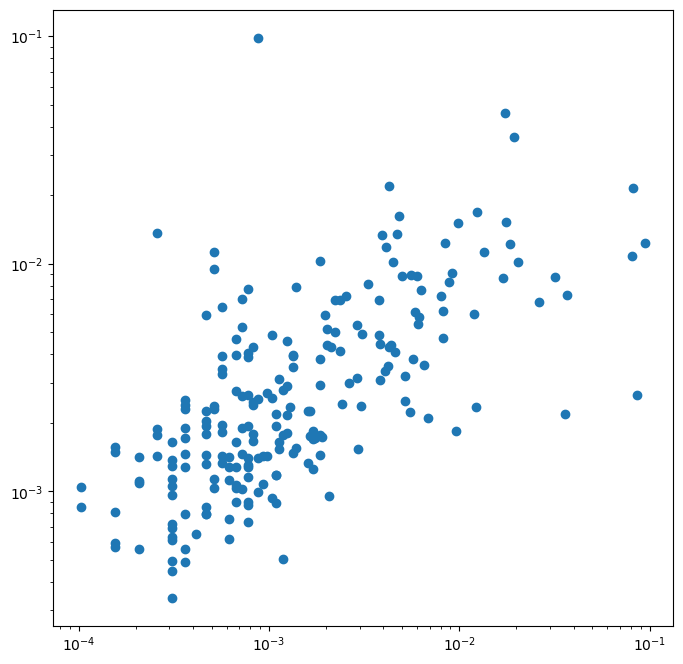

In [35]:
""" Test code. """
_test_asvs, _test_abunds = baseline_test_samples[5].relative_abundance_array(asv_id_subset)
print("input: {} ASVs".format(len(_test_asvs)))
_pred = baseline1.predict_abundances(_test_asvs, max_asvs=len(_test_asvs))
_truth = _test_abunds

corr = scipy.stats.spearmanr(_pred, _truth).statistic
print(f"Spearman corr = {corr}")

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(_truth, _pred)
ax.set_yscale('log')
ax.set_xscale('log')

## *Nearest-neighbor queries:* How good is it, and how does performance decay?

In [36]:
def retrieve_abundances(samples: List[MicrobiomeSample], query_asv: str) -> float:
    """ Return the list of all abundances of the query ASV found in the samples. """
    # if query_asv in abund_cache:
    #     return abund_cache[query_asv]
    
    abund_history = []
    for sample in samples:
        sample_asvs, sample_abunds = sample.relative_abundance_array(asv_id_subset=asv_id_subset)
        sample_abund_dict = {_aid: asv_abund for _aid, asv_abund in zip(sample_asvs, sample_abunds)}
        if query_asv in sample_abund_dict:
            abund_history.append(sample_abund_dict[query_asv])
        else:
            continue

    if len(abund_history) == 0:
        raise ValueError(f"In dataset, found 0 occurrences of ASV {training_neighbor_asv}!")
    
    # abund_cache[query_asv] = abund_history
    return abund_history


from collections import defaultdict

def compute_performance_decay(
    query_asv: str, 
    distance_matrix: ASVDistanceMatrix, 
    training_samples: List[MicrobiomeSample], 
    test_samples: List[MicrobiomeSample],
) -> pd.DataFrame:
    """
    For each asv query, ompute the error for each choice of "neighbor", sorted by distance of that neighbor from the query.
    """
    df_entries = []
    
    # Compute set of training ASVs & their embeddings.
    training_asvs = set()
    for sample in training_samples:
        sample_asvs, _ = sample.relative_abundance_array(asv_id_subset=asv_id_subset)
        training_asvs = training_asvs.union(sample_asvs)
    training_asvs = list(training_asvs)
    
    # Load embeddings from file
    evo_embeddings = dict()
    dnabert_embeddings = dict()
    with h5py.File(DNABERT_S_EMBEDDING_FILE, "r") as dnabert_file, h5py.File(EVO_EMBEDDING_FILE, "r") as evo_file:
        for asv_id in training_asvs + [query_asv]:
            if asv_id not in dnabert_file:
                raise KeyError(f"ASV ID '{asv_id}' not found in embeddings file '{DNABERT_S_EMBEDDING_FILE}'.")
            dnabert_embeddings[asv_id] = torch.tensor(dnabert_file[asv_id][:], dtype=torch.float)
            
            if asv_id not in evo_file:
                raise KeyError(f"ASV ID '{asv_id}' not found in embeddings file '{EVO_EMBEDDING_FILE}'.")
            evo_embeddings[asv_id] = torch.tensor(evo_file[asv_id][:], dtype=torch.float)

    def _embedding_dist(x: Tensor, y: Tensor) -> float:
        return torch.sqrt(torch.sum(torch.square(x - y)))

    # get the row corresonding to the query, with columns restricted to the training ASVs.
    training_indices = [distance_matrix.asv_to_idx[asv] for asv in training_asvs]
    query_row = distance_matrix.matrix[distance_matrix.asv_to_idx[query_asv], :]  # select row
    query_row = query_row[training_indices]   # select columns, same order as training_asvs

    # sort and compute errors.
    query_test_abunds = np.array(retrieve_abundances(test_samples, query_asv), dtype=float)
    training_abunds = defaultdict(list)
    for sample in training_samples:
        for train_asv, train_asv_abund in zip(*sample.relative_abundance_array(asv_id_subset=asv_id_subset)):
            training_abunds[train_asv].append(train_asv_abund)

    # compute errors.
    for training_neighbor_asv, dist in zip(training_asvs, query_row):
        mean_train_weight = geometric_mean(np.array(training_abunds[training_neighbor_asv], dtype=float))
        
        # error = np.abs(mean_train_weight - geometric_mean(np.array(query_test_abunds, dtype=float)))
        error = np.abs(np.log10(mean_train_weight) - np.log10(geometric_mean(np.array(query_test_abunds, dtype=float))))

        dist_dnabert = _embedding_dist(dnabert_embeddings[training_neighbor_asv], dnabert_embeddings[query_asv]).item()
        dist_evo = _embedding_dist(evo_embeddings[training_neighbor_asv], evo_embeddings[query_asv]).item()
        df_entries.append({'Query': query_asv, 'Neighbor': training_neighbor_asv, 'Dist': dist, 'Error': error, 'EmbedDist_DNABERT': dist_dnabert, 'EmbedDist_Evo': dist_evo})
    return pd.DataFrame(df_entries)

SampleMetadata(library_strategy=12544    AMPLICON
Name: library_strategy, dtype: object, library_source=12544    METAGENOMIC
Name: library_source, dtype: object, total_bases=12544    2906433.0
Name: total_bases, dtype: float64, instrument=12544    Illumina MiSeq
Name: instrument, dtype: object, geo_loc_name=12544    canada:unspecified
Name: geo_loc_name, dtype: object, iso=12544    CA
Name: iso, dtype: object, region=12544    Europe and Northern America
Name: region, dtype: object)


<Axes: xlabel='Dist', ylabel='Error'>

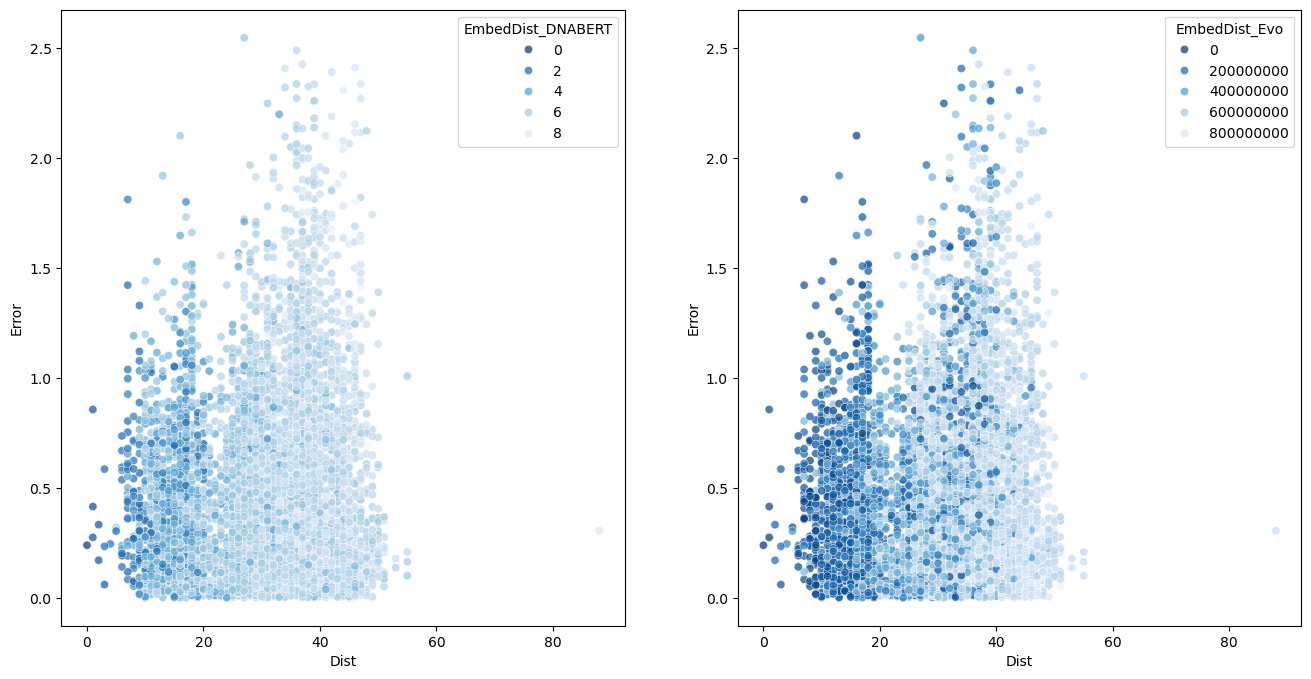

In [37]:
print(baseline_test_samples[0].metadata)
_test_asvs, _test_abunds = baseline_test_samples[1].relative_abundance_array(asv_id_subset)
_df = compute_performance_decay(_test_asvs[1], asv_distance_matrix, baseline_training_samples, baseline_test_samples)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
# sb.scatterplot(_df.loc[_df['Dist'] <= 10], hue='Dist', y='Error', x='EmbedDist_DNABERT', ax=axes[0], palette='Blues_r', alpha=0.7)
# sb.scatterplot(_df.loc[_df['Dist'] <= 10], hue='Dist', y='Error', x='EmbedDist_Evo', ax=axes[1], palette='Blues_r', alpha=0.7)
# sb.scatterplot(_df, hue='Dist', y='Error', x='EmbedDist_DNABERT', ax=axes[0], palette='Blues_r', alpha=0.7)
# sb.scatterplot(_df, hue='Dist', y='Error', x='EmbedDist_Evo', ax=axes[1], palette='Blues_r', alpha=0.7)

sb.scatterplot(_df, hue='EmbedDist_DNABERT', y='Error', x='Dist', ax=axes[0], palette='Blues_r', alpha=0.7)
sb.scatterplot(_df, hue='EmbedDist_Evo', y='Error', x='Dist', ax=axes[1], palette='Blues_r', alpha=0.7)

In [38]:
_df.sort_values('Error')

,Query,Neighbor,Dist,Error,EmbedDist_DNABERT,EmbedDist_Evo
3307,ASV6820,ASV1665197,41,0.000054,7.523258,784956288.0
2785,ASV6820,ASV8484,27,0.000179,6.190212,729150720.0
3405,ASV6820,ASV13115,13,0.000231,6.259593,119372920.0
2281,ASV6820,ASV1832205,17,0.000254,5.751441,306126112.0
2774,ASV6820,ASV9742,31,0.000292,6.852911,361061184.0
...,...,...,...,...,...,...
5231,ASV6820,ASV230657,34,2.406574,7.237521,191589136.0
4325,ASV6820,ASV47627,46,2.410631,7.746027,699371072.0
4020,ASV6820,ASV1681942,37,2.425158,7.182691,703547072.0
5349,ASV6820,ASV2084043,36,2.489141,6.584393,434586176.0


# Baseline model idea #2: Naively compute averages of taxonomic-level abundance lookup across training dataset.

**Description:**
At a defined taxonomic level, for each ASV we compute the average taxonomic total abundance across all training samples.

**Example:**
A sample has exactly 3 ASVs of inferrred genus "Escherichia".
After lookup, we find that the average (e.g. geometric mean) Escherichia relative abundance is 0.3 across all training samples.
Then, each ASV gets assigned a weight of "0.1".
After assigning weights to each ASV this way, we re-normalize the weights to produce estimates for relative abundance.

- *What happens if a test ASV does not have a tax label?* We assign a weight of 0.0 (zero abundance).
- *What happens if a tax label has never been observed before in the training samples?* We assign a weight of 0.0 (zero abundance).

Note that there are two ways to compute these "weights". 
One is by summing up the total abundance of ASVs assigned to that taxa, per sample.
Another way would be to use a third-party tool, such as MetaPhlAn or Kraken.

In [39]:
classification_file = data_base_dir / "classifications.tsv"
assert classification_file.exists()

asv_taxonomies = pd.read_csv(classification_file, sep='\t').fillna("?").set_index('asv_id')
display(asv_taxonomies)

,kingdom,phylum,tclass,torder,family,genus
asv_id,,,,,,
ASV1,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides
ASV2,Bacteria,Bacillota,Bacilli,Lactobacillales,Streptococcaceae,Streptococcus
ASV3,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,Blautia
ASV4,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] gnavus group
ASV5,Bacteria,Bacillota,Bacilli,Staphylococcales,Gemellaceae,Gemella
...,...,...,...,...,...,...
ASV3663366,Bacteria,Pseudomonadota,Gammaproteobacteria,Beggiatoales,Beggiatoaceae,Candidatus Thiopilula
ASV3663367,Bacteria,Pseudomonadota,Gammaproteobacteria,Beggiatoales,Beggiatoaceae,Candidatus Thiopilula
ASV3663368,Bacteria,Pseudomonadota,Gammaproteobacteria,Beggiatoales,Beggiatoaceae,Candidatus Thiopilula


In [40]:
""" Class definition. """
def geometric_mean(x: np.ndarray, eps: float = 1e-6) -> float:
    return np.exp(np.mean(np.log(x + eps)))


class TaxonomicAveragingPredictor:
    TAX_TRY_ORDER = ['genus', 'family', 'torder']
    
    def __init__(self, asv_taxonomies: pd.DataFrame, training_samples: List[MicrobiomeSample]):
        assert len(training_samples) > 0
        self.asv_taxonomies = asv_taxonomies
        self.training_samples = training_samples

    def get_taxon_training_weight(self, tax_level: str, tax_label: str) -> float:
        """
        Compute the average relative abundance of the specified taxonomic label.
        """
        weight_history = []
        for sample in self.training_samples:
            sample_asvs, sample_abunds = sample.relative_abundance_array()
            abund_dict = {_asv: _x for _asv, _x in zip(sample_asvs, sample_abunds)}
            asv_taxonomies = self.asv_taxonomies.loc[sample_asvs]
            asv_taxonomies = asv_taxonomies.loc[asv_taxonomies[tax_level] == tax_label]
            if asv_taxonomies.shape[0] == 0:
                continue
            else:
                sample_wt = sum(
                    abund_dict[asv_id] for asv_id in asv_taxonomies.index
                )
                # print("[{}] {}:{} -> {} ({} ASVs)".format(
                #     sample.sample_id,
                #     tax_level, tax_label,
                #     sample_wt, asv_taxonomies.shape[0]
                # ))
                weight_history.append(sample_wt)
        # raise Exception("STOP HERE")

        if len(weight_history) == 0:
            print(f"[WARNING] In training data, found 0 occurrences of ASVs with label '{tax_label}' at level '{tax_level}'. Defaulting to zero abundance.")
            return 0.0
        return geometric_mean(np.array(weight_history))

    @staticmethod
    def add_padding_1d(pred_vector: np.ndarray, max_size: int) -> np.ndarray:
        if max_size > len(pred_vector):
            pred_vector = np.concatenate([pred_vector, np.zeros(max_size - len(pred_vector), dtype=pred_vector.dtype)])
        return pred_vector

    def predict_weights(self, asv_ids: List[str], tax_level: Optional[str] = None)  -> np.ndarray:
        """
        Make the prediction based on training data.
        """
        print(len(asv_ids), "@", tax_level)
        """ Input validation """
        # Identify what taxonomic level we're trying to parse at.
        if tax_level is None:
            tax_level = self.TAX_TRY_ORDER[0]
            tax_level_idx = 0
        else:
            try:
                tax_level_idx = self.TAX_TRY_ORDER.index(tax_level)
            except ValueError:
                raise ValueError("'level' argument must be one of {}. Got: '{}'".format(
                    self.TAX_TRY_ORDER, tax_level
                ))

        """ Calculate prediction. """
        asv_ordering = {asv_id: idx for idx, asv_id in enumerate(asv_ids)}
        asv_weights = np.zeros(len(asv_ids), dtype=float)
        
        # Group the asvs by taxonomy.
        asv_taxonomies = self.asv_taxonomies.loc[asv_ids]
        assert asv_taxonomies.shape[0] == len(asv_ids), f"Searching for a total of {len(asv_ids)} ASVs, but got only {asv_taxonomies.shape[0]} in the taxonomy dataframe."
        
        for tax_level_label, tax_level_section in asv_taxonomies.groupby(tax_level):
            if tax_level_label == '?':
                """ 
                Handle unknown taxonomic labels --- the 'give up' strategy. 
                """
                unknown_asvs = list(tax_level_section.index)
                print(f"[WARNING] ASVs {unknown_asvs} do not have an identified taxonomy at level '{tax_level}'. These abundance predictions will default to zero.")
                next_level_weights = [0.0] * tax_level_section.shape[0]

                
                """ Handle unknown taxonomic labels --- recursive strategy. """
                """ 
                Note: this is bugged, since it does not take into account the possibility that looking at a higher taxonomic level will cause the weights to be disproportionately larger.
                
                So for instance, if ASV "X" has family/genus "Enterobacteriaceae, Escherichia" and ASV "Y" has family/genus "Enterobacteriaceae, <?>", then "X" will have small weight while "Y" will have big weight (Becuase the lookup happens at Family level)."
                
                A potential fix is to compute "what the average ASV in family Enterobactericeae has", instead of "What the total weight is in Enterobacteriaceae", but even this has issues, since the weights will scale differently depending on the # of ASVs in the sample experiment.
                """
                # if tax_level_idx + 1 == len(self.TAX_TRY_ORDER):
                #     print(f"[WARNING] ASVs {asv_ids} do not have an identified taxonomy at level '{self.TAX_TRY_ORDER[-1]}' or below. These abundance predictions will default to zero.")
                #     next_level_weights = [0.0] * tax_level_section.shape[0]
                # else:                    
                #     # Recursively try next level.
                #     asvs_for_next_level = list(tax_level_section['asv_id'])
                #     asvs_for_next_level = sorted(asvs_for_next_level, key=lambda _asv: asv_ordering[_asv])
                #     next_level_weights = self.predict_weights(asvs_for_next_level, self.TAX_TRY_ORDER[tax_level_idx+1])
            else:
                """ Aggregate weights from training samples. """
                wt = self.get_taxon_training_weight(tax_level, tax_level_label)
                
                # Divide up the weights equally.
                for asv_id in tax_level_section.index:
                    asv_idx = asv_ordering[asv_id]
                    asv_weights[asv_idx] = wt / tax_level_section.shape[0]
                
        return asv_weights

    def predict_abundances(self, asv_ids: List[str], max_asvs: int, tax_level: Optional[str] = None) -> np.ndarray:
        """ Input validation """
        # Assure sizes don't exceed what is specified.
        if len(asv_ids) > max_asvs:
            raise ValueError("Input has more IDs ({}) than the max allotted slots ({})".format(
                len(asv_ids), max_asvs
            ))

        """ Compute output. """
        wts = self.predict_weights(asv_ids, tax_level)
        
        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction; most likely all ASVs in sample have no taxonomy identified at any level.")
        pred = wts / np.sum(wts)
        pred = self.add_padding_1d(pred, max_asvs)
        return pred

    def predict_batch_abundances(self, batched_inputs: List[List[str]], max_asvs: int) -> np.ndarray:
        return np.stack([self.predict_abundances(batch, max_asvs) for batch in batched_inputs], axis=0)

In [41]:
# """ Test code. """
# _test_asvs, _test_abunds = MicrobiomeProject(test_df.iloc[0]['project']).samples[0].relative_abundance_array()
# print("input: {}".format(_test_asvs))
# print(
#     TaxonomicAveragingPredictor(asv_taxonomies, MicrobiomeProject(train_df.iloc[0]['project']).samples).predict_abundances(_test_asvs, max_asvs=len(_test_asvs), tax_level='genus')
# )
# print(_test_abunds)

# Baseline model idea #3: Simple Taxonomic aggregation.

The idea here is to first classify each ASV by taxonomy, and estimate what each relative abundance profile ought to be based on an average across the entire (training) dataset.
For each taxa pair $i, j$, assume that the abundance values $x_i, x_j$ approximately satisfy the following constraint: $\frac{x_i}{x_j} \approx \alpha_{i,j}$, for some constant $\alpha_{i,j}$.
We estimate $\alpha_{ij}$ as the mean abundance ratio across the training dataset:
$$\alpha_{i,j} = \frac{1}{N}\sum_{s=1}^{N} \frac{Abund(i)}{Abund(j)}$$

To make predictions, we solve the following system of equations:
$$
    \left(\begin{array}{c} 1 \\ 0 \\ \vdots \\ 0\end{array}\right)
    =
    \left(
        \begin{array}{c}
            1 & 1 & \cdots & 1 & 1 \\
            1 & -\alpha_{1,2} & 0 & \cdots & 0 \\
            0 & 1 & -\alpha_{2,3} & \cdots & 0 \\
              &   & \vdots & & \\
        \end{array}
    \right)
    \left( 
        \begin{array}{c}
        x_1 \\ x_2 \\ \vdots \\ x_n
        \end{array}
    \right)
$$

# Head-to-head comparison.

In [42]:
def evaluate_method(
    inference_fn: Callable[[MicrobiomeSample], Tuple[List[str], Tensor]],
    test_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    :param inference_fn: A function (e.g. lambda expression) which takes a MicrobiomeSample as input and outputs a (asv_ordering, abund_predictions) tuple. The abund_predictions should be a vector of LOGS of relative abundances.
    :param test_df: A dataframe listing the samples to test on (e.g. test_df in this jupyter notebook).
    """
    # Group by project.
    df_entries = []
    for proj_id, proj_section in tqdm(test_df.groupby("project"), desc="Test Projects"):
        proj = MicrobiomeProject(proj_id)
        test_sample_group = [sample for sample in proj.samples if sample.sample_id in set(proj_section['srs'])]
        for sample in tqdm(test_sample_group, desc=f'Project {proj_id}', total=proj_section.shape[0]):
            """ Ground-truth. """
            true_asv_ids, true_asv_abunds = sample.relative_abundance_array(asv_id_subset)
            true_asv_abunds = torch.tensor(true_asv_abunds, dtype=torch.float)
            assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
            assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"
            assert len(true_asv_ids) == true_asv_abunds.shape[0], "True abundances should have the same size/shape as the list of true ASV ids."
            true_asv_ordering = np.argsort(true_asv_ids)  # sort ASV ids lexicographically
            true_asv_abunds = true_asv_abunds[true_asv_ordering]

            """ Prediction. """
            pred_asv_ids, pred_asv_log_abunds = inference_fn(sample)
            assert isinstance(pred_asv_log_abunds, Tensor), "Expected a tensor for predictions."
            assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the pred abundances."
            assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
            assert len(pred_asv_ids) == pred_asv_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of pred ASV ids."
            pred_asv_ordering = np.argsort(pred_asv_ids)  # sort ASV ids lexicographically
            pred_asv_log_abunds = pred_asv_log_abunds[pred_asv_ordering]

            """ Metric evalaution. """
            assert len(true_asv_ids) == len(pred_asv_ids), f"The number of required ASVs do not match between truth ({len(true_asv_ids)}) and pred ({len(pred_asv_ids)})."

            # KL Divergence
            kl_loss = safe_kl_div_loss(
                pred_asv_log_abunds.unsqueeze(0),
                torch.log(true_asv_abunds.unsqueeze(0)),
            ).item()

            # Root-Mean-Square-Log error
            log_10_conversion = np.log10(np.e)
            rmsle_loss = torch.sqrt(torch.mean(torch.square(
                log_10_conversion * (pred_asv_log_abunds - torch.log(true_asv_abunds))
            ))).item()

            spearman = scipy.stats.spearmanr(pred_asv_log_abunds.numpy(), true_asv_abunds.numpy())
            df_entries.append({
                'Sample': sample.sample_id,
                'KL_err': kl_loss,
                'RMSL_err': rmsle_loss,
                'SpearmanCorr': spearman.statistic,
                'NumASV': len(true_asv_ids),
            })
    return pd.DataFrame(df_entries)
            

def perform_inference_torch_model(torch_model: nn.Module, sample_tensor_converter: MicrobiomeSampleEmbedding, max_num_asvs: int, sample: MicrobiomeSample) -> Tuple[List[str], Tensor]:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of genome embeddings (n_in_batch, MAX_NUM_ASVS, embedding_dim), which was trained using the function 'main_training_loop'. This model should output logits.
    :param sample: A sample on which to perform inference on.
    """
    asv_ordering, input_features, _, asv_mask = sample_tensor_converter.convert(sample, max_num_asvs)
    assert len(input_features.shape) == 2, f"Expected a 2-d tensor for input_features (n_genomes, genome_embed_dim), got: {input_features.shape}"
    assert len(asv_mask.shape) == 1, f"Expected a 1-d tensor for asv_mask (n_genomes), got: {input_features.shape}"
    assert input_features.shape[0] == max_num_asvs, f"Expected input features dim=0 shape to match max_num_asvs ({max_num_asvs}), got: {input_features.shape[0]}"
    assert asv_mask.shape[0] == max_num_asvs, f"Expected input features dim=0 shape to match max_num_asvs ({max_num_asvs}), got: {asv_mask.shape[0]}"
    
    input_features = input_features.unsqueeze(0)
    asv_mask = asv_mask.unsqueeze(0)

    torch_model.eval()
    with torch.no_grad():
        nn_output = torch_model(input_features.cuda(), asv_mask.cuda()).to("cpu").to(torch.float32)
        assert len(nn_output.shape) == 2, f"Expected output of model to be a 2-d tensor of batched relative abundance profiles (potentially with padding). Got: {nn_output.shape}"
        assert nn_output.shape[0] == 1, f"Expected output of model to start with leading dim of size 1, since evaluation is done on one sample at a time. Got: {pred_tensor.shapt[0]}"
        assert nn_output.shape[1] == max_num_asvs, f"Expected output of model to have second dim of size {max_num_asvs}, indexed by ASVs. got: {nn_output.shape[1]}"
        assert len(asv_ordering) == asv_mask[0].sum(), f"Expected the number of 'True' entries in mask ({asv_mask[0].sum()}) to match # of asvs ({len(asv_ordering)})."
        n_finite_nn = (~torch.isinf(nn_output[0])).sum()
        assert len(asv_ordering) == n_finite_nn, f"Expected the number of finite entries in model output ({n_finite_nn}) to match # of asvs ({len(asv_ordering)})."
        
        nn_output = nn_output[0][:len(asv_ordering)]
        n_finite_nn_slice = (~torch.isinf(nn_output)).sum()
        assert len(asv_ordering) == n_finite_nn_slice, f"Expected the first {len(asv_ordering)} entries of model output to all be finite."
        gc.collect()
        torch.cuda.empty_cache()
        log_prob_output = nn.functional.log_softmax(nn_output, dim=-1)    # log probabilities

    return asv_ordering, log_prob_output


def evaluate_torch_model(
    model_config_file: Path,
    model_state_file: Path,
    test_df: pd.DataFrame,
    input_mapping: MicrobiomeSampleEmbedding,
    max_num_asvs: int,
) -> pd.DataFrame:
    """ 
    A wrapper around the previously-defined 'evaluate_method' function. 
    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert model_state_file.exists(), f"Pytorch model state '{model_state_file}' does not exist! Was it trained and saved?"
        
    model_cfg = create_model_config(model_config_file, rng_seed=12345)  # rng_seed doesn't matter here since we are loading the model from file.
    model = AbundancePredictionModel(**model_cfg).to("cuda")
    model = torch.compile(model)
    model.load_state_dict(torch.load(model_state_file, weights_only=True))
    model.eval()

    num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Loaded model {model_config_file} | Num. trainable parameters = {num_trainable_params}')
    
    return evaluate_method(
        lambda _sample: perform_inference_torch_model(model, input_mapping, max_num_asvs, _sample), 
        test_df
    )


def perform_inference_baseline1(sample: MicrobiomeSample) -> Tuple[List[str], Tensor]:
    asv_ordering = list(sample.asv_ids.intersection(asv_id_subset))
    abunds = baseline1.predict_abundances(asv_ordering, max_asvs=len(asv_ordering))
    assert np.abs(abunds.sum() - 1.0) < 1e-6, "expected rel. abunds to sum to 1.0. Got: {} (abs difference of {})".format(abunds.sum(), np.abs(abunds.sum() - 1.0))

    # add padding so that we can properly evaluate KL divergence.
    abunds = abunds + 1e-7
    abunds = abunds / np.sum(abunds)
    
    abunds = torch.tensor(abunds, dtype=torch.float32)
    return asv_ordering, torch.log(abunds)
    

In [43]:
saved_models

{'dnabert-s': (PosixPath('configs/embed_dnabert-s.depth_4.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_dnabert-s.D_4.L_kl.E_200.pt')),
 'evo': (PosixPath('configs/embed_evo.depth_4.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_evo.D_4.L_kl.E_300.pt')),
 'dnabert-s:depth=0': (PosixPath('configs/embed_dnabert-s.depth_0.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_dnabert-s.D_0.L_kl.E_200.pt')),
 'evo:depth=0': (PosixPath('configs/embed_evo.depth_0.yaml'),
  PosixPath('__tmp/american_gut_USCA/trained_models/model.embed_evo.D_0.L_kl.E_300.pt'))}

In [44]:
input_mapping_evo = MicrobiomeSampleEmbedding(EVO_EMBEDDING_FILE, asv_id_subset, cache_embeddings=False)
input_mapping_dnabert_s = MicrobiomeSampleEmbedding(DNABERT_S_EMBEDDING_FILE, asv_id_subset, cache_embeddings=False)

# model_config_file, model_state_path
eval_result_df = pd.concat([
    evaluate_torch_model(saved_models['evo'][0], saved_models['evo'][1], test_df, input_mapping_evo, MAX_NUM_ASVS).assign(Method='evo_ft_context'),
    evaluate_torch_model(saved_models['evo:depth=0'][0], saved_models['evo:depth=0'][1], test_df, input_mapping_evo, MAX_NUM_ASVS).assign(Method='evo_ft_indep'),
    evaluate_torch_model(saved_models['dnabert-s'][0], saved_models['dnabert-s'][1], test_df, input_mapping_dnabert_s, MAX_NUM_ASVS).assign(Method='dnabert-s_ft_context'),
    evaluate_torch_model(saved_models['dnabert-s:depth=0'][0], saved_models['dnabert-s:depth=0'][1], test_df, input_mapping_dnabert_s, MAX_NUM_ASVS).assign(Method='dnabert-s_ft_indep'),
    evaluate_method(perform_inference_baseline1, test_df).assign(Method='baseline1')
])

Loading tensor embeddings from __tmp/american_gut_USCA/embeddings.evo.h5 (genome embedding shape = torch.Size([4096]))
Loading tensor embeddings from __tmp/american_gut_USCA/embeddings.dnabert-s.h5 (genome embedding shape = torch.Size([768]))
Loaded model configs/embed_evo.depth_4.yaml | Num. trainable parameters = 11129113


Test Projects:   0%|          | 0/1 [00:00<?, ?it/s]

Project PRJEB11419:   0%|          | 0/118 [00:00<?, ?it/s]

/data/local/youn/miniforge3/envs/evo/lib/python3.11/site-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Loaded model configs/embed_evo.depth_0.yaml | Num. trainable parameters = 420101


...

Loaded model configs/embed_dnabert-s.depth_0.yaml | Num. trainable parameters = 87301


Test Projects:   0%|          | 0/1 [00:00<?, ?it/s]

Project PRJEB11419:   0%|          | 0/118 [00:00<?, ?it/s]

Test Projects:   0%|          | 0/1 [00:00<?, ?it/s]

Project PRJEB11419:   0%|          | 0/118 [00:00<?, ?it/s]

In [45]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, ax=None, hue_order=None, palette=None, correction='fdr_bh'):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.5, edgecolor='black', linewidth=1.0)
    ax.set_xticklabels(hue_order, rotation=30)
    
    # Get y-axis range for proper scaling
    ylim = ax.get_ylim()
    y_range = ylim[1] - ylim[0]
    y_max = data[y].max()
    
    # Starting position for annotations (4% above data max)
    y_start = y_max + y_range * 0.04
    
    # Pairwise significance testing
    pairs = list(itertools.combinations(hue_order, 2))
    p_values = []
    test_results = []
    
    # Collect all p-values first
    for h1, h2 in pairs:
        d1 = data[data[hue] == h1][[sample_col, y]]
        d2 = data[data[hue] == h2][[sample_col, y]]
        joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
        v1 = joined[y + '_1']
        v2 = joined[y + '_2']
        stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
        p_values.append(p)
        test_results.append((h1, h2, stat, p))
    
    # Apply multiple hypothesis correction
    if len(p_values) > 1:
        rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
    else:
        rejected = [p_values[0] < 0.05] if p_values else []
        p_corrected = p_values
    
    # Annotation with corrected p-values
    annotation_idx = 0  # Counter for positioning annotations
    for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
        p_adj = p_corrected[idx]
        
        stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
        
        x1, x2 = group_locs[h1], group_locs[h2]
        
        # Calculate bracket position and height based on y-axis range
        y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
        bracket_height = y_range * 0.02  # 2% of y-range for bracket height
        text_offset = y_range * 0.001  # offset for text above bracket
        
        # Draw significance bracket
        ax.plot([x1, x1, x2, x2], 
                [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                lw=1.2, c='k')
        
        # Add significance text with adjusted p-value info
        text = f"{stars}"
        ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                text, ha='center', va='bottom', color='k', fontsize=11)
        
        annotation_idx += 1
    
    # Add correction method info to plot
    ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
            transform=ax.transAxes, verticalalignment='top', fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    
    plt.tight_layout()
    return ax

/tmp/ipykernel_2756329/3324913018.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=30)
/tmp/ipykernel_2756329/3324913018.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=30)
/tmp/ipykernel_2756329/3324913018.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=30)


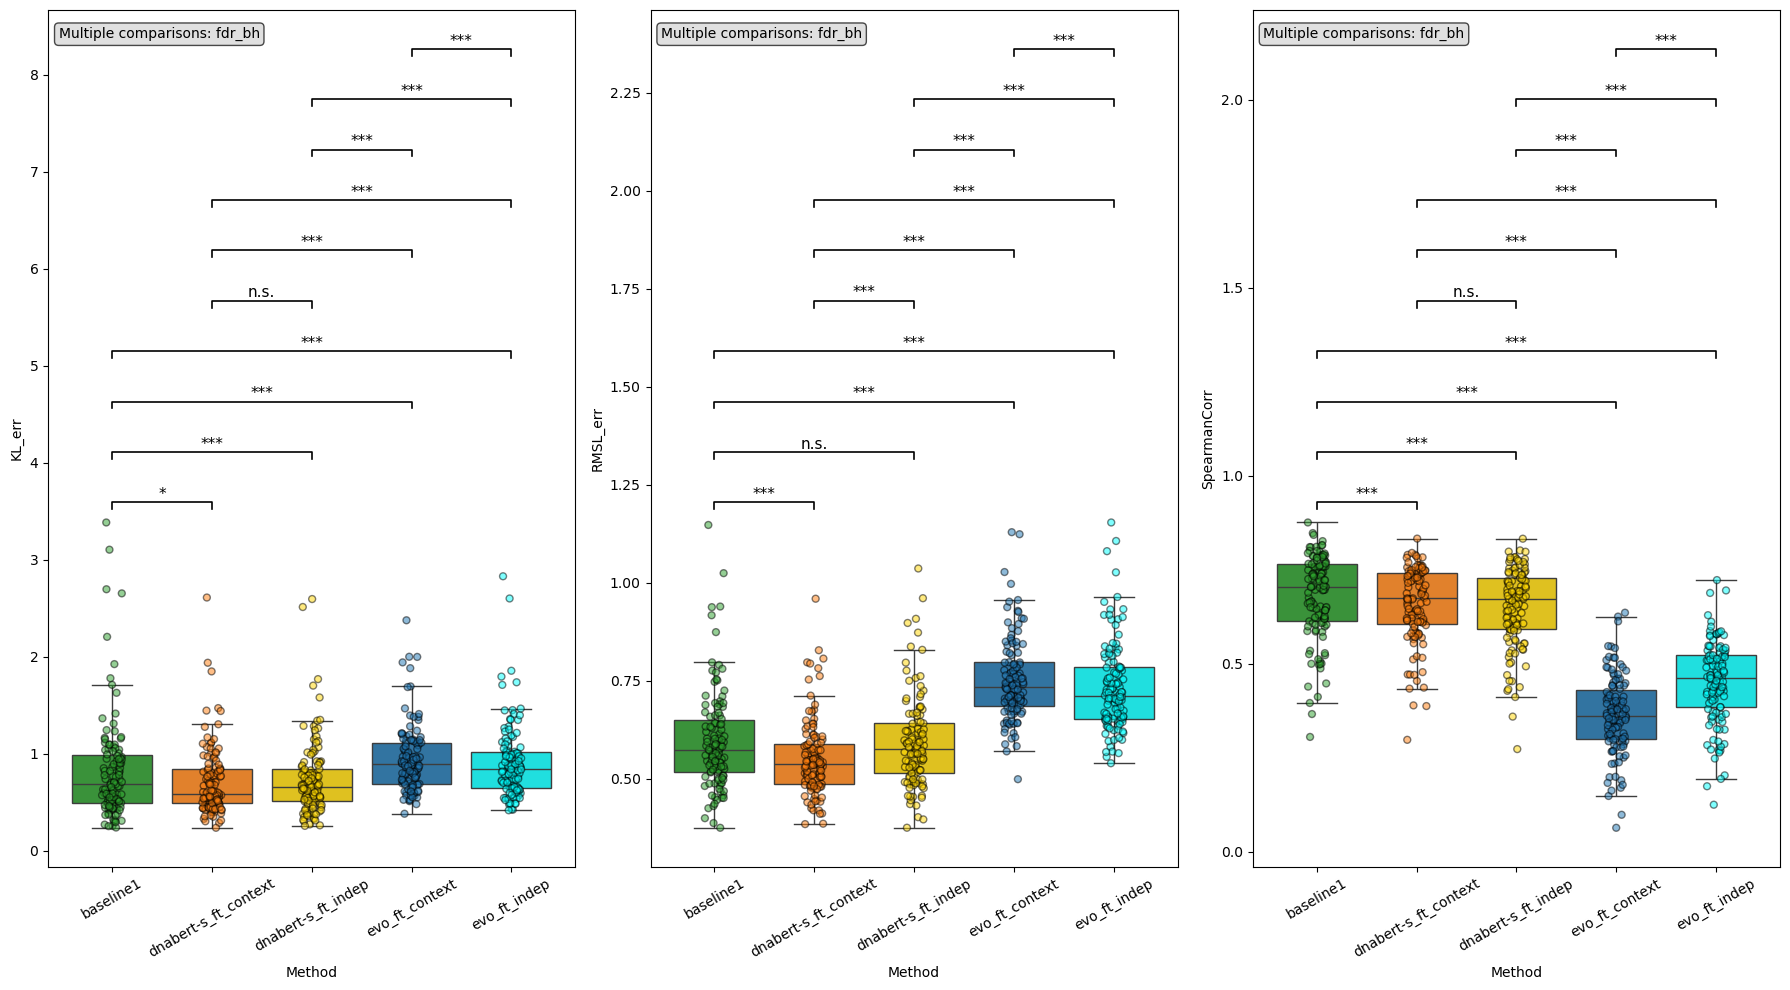

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
axes = axes.flatten()
palette = {
    'evo_ft_context': 'tab:blue',
    'dnabert-s_ft_context': 'tab:orange',
    'evo_ft_indep': 'cyan',
    'dnabert-s_ft_indep': 'gold',
    'baseline1': 'tab:green',
}

boxplot_with_paired_significance(eval_result_df, hue='Method', y='KL_err', sample_col='Sample', ax=axes[0], palette=palette)
boxplot_with_paired_significance(eval_result_df, hue='Method', y='RMSL_err', sample_col='Sample', ax=axes[1], palette=palette)
boxplot_with_paired_significance(eval_result_df, hue='Method', y='SpearmanCorr', sample_col='Sample', ax=axes[2], palette=palette)


# sb.scatterplot(
#     eval_result_df,
#     x='NumASV', y='KL_err',
#     hue='Method', ax=axes[3], palette=palette
# )
plt.savefig("plots/USCA_benchmark.png", bbox_inches='tight')